In [1]:
import pyarrow.parquet as pq
from pathlib import Path

DATA_PATH = Path(r"D:\SEM 7\CAPSTONE\DATA\slusi\SLUSI_Soil_Health_data.16-5037---7-8388--125-3251--41-5041.parquet")

pf = pq.ParquetFile(DATA_PATH)
meta = pf.metadata

print(f"File size     : {DATA_PATH.stat().st_size / 1e9:.2f} GB")
print(f"Rows          : {meta.num_rows:,}")
print(f"Columns       : {meta.num_columns}")
print(f"Row groups    : {meta.num_row_groups}")
print(f"Rows/group(1st): {meta.row_group(0).num_rows:,}")
print()

schema = pf.schema_arrow
print(f"{'#':>3}  {'column':<14} {'arrow type'}")
print("-" * 40)
for i, field in enumerate(schema):
    print(f"{i:>3}  {field.name:<14} {field.type}")

File size     : 0.22 GB
Rows          : 5,182,371
Columns       : 46
Row groups    : 5
Rows/group(1st): 1,048,576

  #  column         arrow type
----------------------------------------
  0  id             string
  1  VILLAGE        string
  2  MANDAL         string
  3  DISTRICT       string
  4  DMV_Code       string
  5  Parcel_num     string
  6  Shape_Area     string
  7  ORIG_FID       string
  8  Parcel_n_1     string
  9  surveyNo       string
 10  address        string
 11  village_1      string
 12  computedID     string
 13  date           string
 14  N              string
 15  P              string
 16  K              string
 17  pH             string
 18  EC             string
 19  OC             string
 20  B              string
 21  BLOCK          string
 22  Category       string
 23  Fe             string
 24  Zn             string
 25  fe_1           string
 26  Mn             string
 27  Cu             string
 28  S              string
 29  STATE          string
 30

In [2]:
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)

first_batch = next(pf.iter_batches(batch_size=10))
sample = first_batch.to_pandas()

sample.T

,0,1,2,3,4,5,6,7,8,9
id,23_432_shc_2023-24.1002,23_432_shc_2023-24.9680,23_432_shc_2023-24.13611,23_432_shc_2023-24.13629,23_432_shc_2023-24.13630,23_432_shc_2023-24.13631,23_432_shc_2023-24.16385,23_432_shc_2023-24.16386,23_432_shc_2023-24.11025,23_432_shc_2023-24.17658
VILLAGE,None,None,None,None,None,None,None,None,None,None
MANDAL,None,None,None,None,None,None,None,None,None,None
DISTRICT,None,None,None,None,None,None,None,None,None,None
DMV_Code,None,None,None,None,None,None,None,None,None,None
Parcel_num,None,None,None,None,None,None,None,None,None,None
Shape_Area,None,None,None,None,None,None,None,None,None,None
ORIG_FID,None,None,None,None,None,None,None,None,None,None
Parcel_n_1,None,None,None,None,None,None,None,None,None,None
surveyNo,1123/2,2552,115/2,165,165,655/2,623/1,1655,9962/1,165/9


In [3]:
import pyarrow.compute as pc
import time

t0 = time.time()
table = pq.read_table(DATA_PATH)
print(f"Loaded {table.num_rows:,} rows in {time.time()-t0:.1f}s")

# Official Maharashtra district codes (as strings, to match the file)
MH_DISTRICTS = {
    "466": "AHILYANAGAR", "467": "AKOLA", "468": "AMRAVATI", "469": "Chhatrapati Sambhajinagar",
    "470": "BEED", "471": "BHANDARA", "472": "BULDHANA", "473": "CHANDRAPUR", "474": "DHULE",
    "475": "GADCHIROLI", "476": "GONDIA", "477": "HINGOLI", "478": "JALGAON", "479": "JALNA",
    "480": "KOLHAPUR", "481": "LATUR", "482": "Mumbai", "483": "MUMBAI SUBURBAN", "484": "NAGPUR",
    "485": "NANDED", "486": "NANDURBAR", "487": "NASHIK", "488": "DHARASHIV", "489": "PARBHANI",
    "490": "PUNE", "491": "RAIGAD", "492": "RATNAGIRI", "493": "SANGLI", "494": "SATARA",
    "495": "SINDHUDURG", "496": "SOLAPUR", "497": "THANE", "498": "WARDHA", "499": "WASHIM",
    "500": "YAVATMAL", "665": "PALGHAR",
}
mh_codes = pa.array(list(MH_DISTRICTS.keys())) if (pa := __import__("pyarrow")) else None

# State/district code from the id prefix: "27_490_shc_..." -> "27", "490"
parts = pc.split_pattern(table["id"], "_")
id_sid = pc.list_element(parts, 0)
id_did = pc.list_element(parts, 1)

sid, did = table["sid"], table["did"]

by_sid = pc.equal(sid, "27")
by_id  = pc.equal(id_sid, "27")

def n(mask): return pc.sum(pc.fill_null(mask, False).cast("int64")).as_py()

print(f"\nNull id: {table['id'].null_count:,} | null sid: {sid.null_count:,} | null did: {did.null_count:,}")
print(f"\nRows with sid == 27      : {n(by_sid):,}")
print(f"Rows with id prefix == 27: {n(by_id):,}")
print(f"Both agree (27 in both)  : {n(pc.and_(by_sid, by_id)):,}")
print(f"sid==27 but id says no   : {n(pc.and_(by_sid, pc.invert(by_id))):,}")
print(f"id says 27 but sid no    : {n(pc.and_(by_id, pc.invert(by_sid))):,}")

# Among Maharashtra rows (either source), check district codes
any_mh = pc.or_(pc.fill_null(by_sid, False), pc.fill_null(by_id, False))
print(f"\nAmong MH rows ({n(any_mh):,}):")
print(f"  did == id district        : {n(pc.and_(any_mh, pc.equal(did, id_did))):,}")
print(f"  did in official 36 codes  : {n(pc.and_(any_mh, pc.is_in(did, value_set=mh_codes))):,}")
print(f"  id district in official 36: {n(pc.and_(any_mh, pc.is_in(id_did, value_set=mh_codes))):,}")

Loaded 5,182,371 rows in 0.9s

Null id: 0 | null sid: 0 | null did: 0

Rows with sid == 27      : 355,562
Rows with id prefix == 27: 355,562
Both agree (27 in both)  : 355,562
sid==27 but id says no   : 0
id says 27 but sid no    : 0

Among MH rows (355,562):
  did == id district        : 355,562
  did in official 36 codes  : 355,562
  id district in official 36: 355,562


In [4]:
OUT_DIR = Path(r"D:\SEM 7\CAPSTONE\DATA\slusi\Start")
OUT_DIR.mkdir(parents=True, exist_ok=True)
MH_PATH = OUT_DIR / "maharashtra_raw.parquet"

mh = table.filter(pc.equal(table["sid"], "27"))
pq.write_table(mh, MH_PATH, compression="zstd")

# Verify what was written by reading it back from disk
check = pq.ParquetFile(MH_PATH).metadata
print(f"Saved : {MH_PATH}")
print(f"Size  : {MH_PATH.stat().st_size / 1e6:.1f} MB")
print(f"Rows  : {check.num_rows:,}  | Columns: {check.num_columns}")
print(f"Schema identical to master: {pq.read_schema(MH_PATH).equals(table.schema)}")

# Records per district
dist_counts = (
    pc.value_counts(mh["did"]).to_pandas()
    .rename(columns={"values": "did", "counts": "records"})
)
dist_counts["district"] = dist_counts["did"].map(MH_DISTRICTS)
dist_counts = dist_counts.sort_values("records", ascending=False).reset_index(drop=True)
print(f"\nDistricts present: {len(dist_counts)} of 36")
print(dist_counts[["did", "district", "records"]].to_string())

Saved : D:\SEM 7\CAPSTONE\DATA\slusi\Start\maharashtra_raw.parquet
Size  : 16.0 MB
Rows  : 355,562  | Columns: 46
Schema identical to master: True


TypeError: Series.rename() got an unexpected keyword argument 'columns'

In [5]:
# Records per district (the file above is already saved and verified; this only summarises it)
dist_counts = (
    mh["did"].to_pandas()
    .value_counts()
    .rename_axis("did")
    .reset_index(name="records")
)
dist_counts["district"] = dist_counts["did"].map(MH_DISTRICTS)

print(f"Districts present: {len(dist_counts)} of {len(MH_DISTRICTS)}")
missing = sorted(set(MH_DISTRICTS) - set(dist_counts["did"]))
print(f"Districts with no records: {[f'{d} {MH_DISTRICTS[d]}' for d in missing] or 'none'}")
print()
print(dist_counts[["did", "district", "records"]].to_string())

Districts present: 34 of 36
Districts with no records: ['482 Mumbai', '483 MUMBAI SUBURBAN']

    did                   district  records
0   487                     NASHIK    22788
1   494                     SATARA    21982
2   466                AHILYANAGAR    15829
3   490                       PUNE    14752
4   473                 CHANDRAPUR    14178
5   472                   BULDHANA    14158
6   480                   KOLHAPUR    13660
7   475                 GADCHIROLI    13267
8   496                    SOLAPUR    13259
9   468                   AMRAVATI    12221
10  493                     SANGLI    11639
11  471                   BHANDARA    11361
12  485                     NANDED    11330
13  478                    JALGAON    11151
14  481                      LATUR    10828
15  474                      DHULE     9988
16  491                     RAIGAD     9722
17  484                     NAGPUR     9321
18  486                  NANDURBAR     9274
19  469  Chhatrapati Sambh

In [6]:
import numpy as np
import shapely

# Decode all WKB points at once (vectorised, no per-row loop)
t0 = time.time()
geoms = shapely.from_wkb(mh["geometry"].to_numpy(zero_copy_only=False))
lon = shapely.get_x(geoms)
lat = shapely.get_y(geoms)
print(f"Decoded {len(geoms):,} geometries in {time.time()-t0:.1f}s")

types = pd.Series(shapely.get_type_id(geoms)).map({0: "Point"}).fillna("other/None")
print(f"Geometry types: {types.value_counts().to_dict()}")
print(f"NaN lon/lat   : {np.isnan(lon).sum():,} / {np.isnan(lat).sum():,}")
print(f"lon range     : {np.nanmin(lon):.5f} .. {np.nanmax(lon):.5f}")
print(f"lat range     : {np.nanmin(lat):.5f} .. {np.nanmax(lat):.5f}")

# Rough Maharashtra bounding box (lon 72.6-80.9, lat 15.6-22.1)
outside = ~((lon >= 72.6) & (lon <= 80.9) & (lat >= 15.6) & (lat <= 22.1))
print(f"Outside MH bbox: {outside.sum():,}")

# Duplicate-GPS structure (exact coordinate match)
coords = pd.DataFrame({"lon": lon, "lat": lat})
grp_size = coords.groupby(["lon", "lat"]).size()
print(f"\nRecords          : {len(coords):,}")
print(f"Unique GPS points: {len(grp_size):,}  ({len(grp_size)/len(coords):.2%})")
print(f"Points with >1 record: {(grp_size > 1).sum():,}  holding {grp_size[grp_size > 1].sum():,} records")
print("\nRecords per GPS point:")
print(grp_size.value_counts().sort_index().head(15).to_string())
print(f"Max records at one point: {grp_size.max():,}")

Decoded 355,562 geometries in 0.3s
Geometry types: {'Point': 355562}
NaN lon/lat   : 0 / 0
lon range     : 72.55321 .. 91.78704
lat range     : 15.62376 .. 26.12031
Outside MH bbox: 10

Records          : 355,562
Unique GPS points: 246,285  (69.27%)
Points with >1 record: 31,490  holding 140,767 records

Records per GPS point:
1     214795
2      15563
3       4728
4       2887
5       1950
6       1324
7        914
8        745
9        557
10       482
11       355
12       297
13       227
14       171
15       167
Max records at one point: 112


In [7]:
cols = ["id", "did", "VILLAGE", "date", "N", "P", "K", "OC", "cycle"]
df = mh.select(cols).to_pandas()
df["district"] = df["did"].map(MH_DISTRICTS)
df["lon"], df["lat"] = lon, lat

# 1) The 10 points outside the Maharashtra bbox
print("=== Outside MH bbox ===")
print(df.loc[outside, ["id", "district", "VILLAGE", "lon", "lat", "date"]].to_string())

# 2) What do repeated GPS points contain?
df["n_at_point"] = df.groupby(["lon", "lat"])["id"].transform("size")
rep = df[df["n_at_point"] > 1]
g = rep.groupby(["lon", "lat"])
summ = pd.DataFrame({
    "records":    g.size(),
    "districts":  g["did"].nunique(),
    "villages":   g["VILLAGE"].nunique(),
    "dates":      g["date"].nunique(),
    "cycles":     g["cycle"].nunique(),
    "npk_combos": g[["N", "P", "K"]].apply(lambda x: len(x.drop_duplicates())),
})

print(f"\n=== Repeated GPS points: {len(summ):,} ===")
print(f"Span >1 district           : {(summ['districts'] > 1).sum():,}")
print(f"Span >1 village            : {(summ['villages'] > 1).sum():,}")
print(f"All records same N,P,K      : {(summ['npk_combos'] == 1).sum():,}  (likely true duplicates)")
print(f"Different N,P,K at the point: {(summ['npk_combos'] > 1).sum():,}  (distinct samples sharing a GPS)")
print(f"\nDistinct dates per point : {summ['dates'].value_counts().sort_index().head(8).to_dict()}")
print(f"Distinct cycles per point: {summ['cycles'].value_counts().sort_index().to_dict()}")

print("\n=== 5 most crowded points ===")
print(summ.sort_values("records", ascending=False).head(5).to_string())

=== Outside MH bbox ===
                             id district VILLAGE        lon        lat               date
336736  27_491_shc_2023-24.2099   RAIGAD    None  72.553211  18.972318  2/26/24, 12:00 AM
336737   27_491_shc_2023-24.964   RAIGAD    None  72.553211  18.972318  4/30/24, 12:00 AM
336738  27_491_shc_2023-24.1272   RAIGAD    None  72.553211  18.972318  4/30/24, 12:00 AM
355555  27_499_shc_2023-24.2517   WASHIM    None  91.787044  26.120298  3/31/24, 12:00 AM
355556  27_499_shc_2023-24.2518   WASHIM    None  91.787044  26.120298  3/31/24, 12:00 AM
355557  27_499_shc_2023-24.2519   WASHIM    None  91.787044  26.120298  3/31/24, 12:00 AM
355558  27_499_shc_2023-24.2520   WASHIM    None  91.787016  26.120310  3/31/24, 12:00 AM
355559  27_499_shc_2023-24.3382   WASHIM    None  91.787044  26.120298  3/31/24, 12:00 AM
355560  27_499_shc_2023-24.4173   WASHIM    None  91.787044  26.120298  3/31/24, 12:00 AM
355561  27_499_shc_2023-24.5044   WASHIM    None  91.787044  26.120298  3/31

In [8]:
import mgrs

PILOT_PATH = OUT_DIR / "pilot_1000.parquet"
N_PILOT, SEED = 1000, 42

base = mh.to_pandas()
base["longitude"], base["latitude"] = lon, lat
base["sample_date"] = pd.to_datetime(base["date"], format="%m/%d/%y, %I:%M %p", errors="coerce")
print(f"Non-null date strings: {base['date'].notna().sum():,} | parsed: {base['sample_date'].notna().sum():,}")

# Eligible = only record at its GPS point, has a date, inside MH bbox, numeric N/P/K
n_at_point = base.groupby(["longitude", "latitude"])["id"].transform("size")
has_npk = base[["N", "P", "K"]].apply(pd.to_numeric, errors="coerce").notna().all(axis=1)
eligible = base[(n_at_point == 1) & base["sample_date"].notna() & ~outside & has_npk]
print(f"Eligible records: {len(eligible):,}")

pilot = eligible.sample(n=N_PILOT, random_state=SEED).reset_index(drop=True)
m = mgrs.MGRS()
pilot["mgrs_tile"] = [m.toMGRS(la, lo, MGRSPrecision=0) for lo, la in zip(pilot["longitude"], pilot["latitude"])]

print(f"\nPilot rows       : {len(pilot):,}")
print(f"Districts        : {pilot['did'].nunique()}")
print(f"MGRS tiles       : {pilot['mgrs_tile'].nunique()}")
print(f"Unique dates     : {pilot['sample_date'].nunique()}")
print(f"Tile-date groups : {pilot.groupby(['mgrs_tile', 'sample_date']).ngroups}")
print(f"Date range       : {pilot['sample_date'].min().date()} .. {pilot['sample_date'].max().date()}")

pilot.to_parquet(PILOT_PATH, index=False)
print(f"\nSaved: {PILOT_PATH}")

Non-null date strings: 250,672 | parsed: 250,672
Eligible records: 119,814

Pilot rows       : 1,000
Districts        : 34
MGRS tiles       : 51
Unique dates     : 194
Tile-date groups : 695
Date range       : 2023-09-18 .. 2024-07-31

Saved: D:\SEM 7\CAPSTONE\DATA\slusi\Start\pilot_1000.parquet


In [9]:
import json
from pystac_client import Client

STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"
MAX_CLOUD, WINDOW = 10, 3          # scene cloud cover < 10 %, +/- 3 days
SCENES_PATH  = OUT_DIR / "pilot_1000_scenes.parquet"
MATCHES_PATH = OUT_DIR / "pilot_1000_matches.parquet"

catalog = Client.open(STAC_URL)

def scene_tile(item):
    return item.properties.get("s2:mgrs_tile") or item.id.split("_")[5][1:]

# ---- 1) ONE STAC search per MGRS tile (cloud filter applied server-side) ----
tile_items, n_requests = {}, 0
t0 = time.time()
for tile, tdf in pilot.groupby("mgrs_tile"):
    bbox = [tdf["longitude"].min(), tdf["latitude"].min(), tdf["longitude"].max(), tdf["latitude"].max()]
    start = (tdf["sample_date"].min() - pd.Timedelta(days=WINDOW)).strftime("%Y-%m-%d")
    end   = (tdf["sample_date"].max() + pd.Timedelta(days=WINDOW)).strftime("%Y-%m-%d")
    for attempt in range(5):
        try:
            n_requests += 1
            search = catalog.search(
                collections=["sentinel-2-l2a"], bbox=bbox, datetime=f"{start}/{end}",
                query={"eo:cloud_cover": {"lt": MAX_CLOUD}}, limit=500,
            )
            tile_items[tile] = [it for it in search.items() if scene_tile(it) == tile]
            break
        except Exception as e:
            wait = 5 * 2 ** attempt
            print(f"  {tile}: {type(e).__name__} -> retry in {wait}s")
            time.sleep(wait)
    else:
        raise RuntimeError(f"Search failed for tile {tile}")
    time.sleep(0.25)

scene_items = {it.id: it for items in tile_items.values() for it in items}
print(f"Tiles searched : {len(tile_items)} | requests: {n_requests} | {time.time()-t0:.1f}s")
print(f"Scenes (<{MAX_CLOUD}% cloud, own tile): {len(scene_items):,}")

# Save scene metadata + full STAC item JSON so we never have to search again
scenes_df = pd.DataFrame([{
    "sentinel_scene_id": it.id,
    "mgrs_tile": scene_tile(it),
    "sentinel_datetime": pd.Timestamp(it.datetime).tz_convert(None),
    "scene_cloud_cover": it.properties.get("eo:cloud_cover"),
    "item_json": json.dumps(it.to_dict()),
} for it in scene_items.values()])
scenes_df.to_parquet(SCENES_PATH, index=False)

# ---- 2) Match samples to scenes locally (no more API calls) ----
matches = pilot[["id", "sample_date", "longitude", "latitude", "mgrs_tile"]].merge(
    scenes_df.drop(columns="item_json"), on="mgrs_tile")
matches["date_difference_days"] = (matches["sentinel_datetime"].dt.normalize() - matches["sample_date"]).dt.days
matches = matches[matches["date_difference_days"].abs() <= WINDOW].reset_index(drop=True)
matches.to_parquet(MATCHES_PATH, index=False)

per_sample = matches.groupby("id").size()
per_scene  = matches.groupby("sentinel_scene_id").size()
print(f"\nSample-scene pairs     : {len(matches):,}")
print(f"Samples with >=1 scene : {len(per_sample):,} of {len(pilot):,}")
print(f"Scenes actually needed : {len(per_scene):,}")
print(f"Scenes per sample      : {per_sample.value_counts().sort_index().to_dict()}")
print(f"Samples per scene      : median {per_scene.median():.0f}, max {per_scene.max()}")
print(f"\nSaved: {SCENES_PATH.name}, {MATCHES_PATH.name}")

C:\Users\pares\AppData\Roaming\Python\Python313\site-packages\pystac_client\item_search.py:243: DoesNotConformTo: Server does not conform to QUERY
  warnings.warn(DoesNotConformTo("QUERY"))


Tiles searched : 51 | requests: 51 | 71.9s
Scenes (<10% cloud, own tile): 1,031

Sample-scene pairs     : 667
Samples with >=1 scene : 406 of 1,000
Scenes actually needed : 364
Scenes per sample      : {1: 231, 2: 104, 3: 57, 4: 13, 5: 1}
Samples per scene      : median 1, max 11

Saved: pilot_1000_scenes.parquet, pilot_1000_matches.parquet


In [10]:
import requests
import rasterio
from rasterio.windows import Window
from pyproj import Transformer
import planetary_computer as planetary
from concurrent.futures import ThreadPoolExecutor

ASSETS = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12","SCL","AOT","WVP"]

# GDAL settings for fast remote COG access
GDAL_OPTS = dict(
    GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
    CPL_VSIL_CURL_ALLOWED_EXTENSIONS=".tif",
    GDAL_HTTP_MERGE_CONSECUTIVE_RANGES="YES",
    GDAL_HTTP_MULTIPLEX="YES",
    GDAL_HTTP_VERSION="2",
    VSI_CACHE="TRUE",
)

bench = matches.sample(5, random_state=42).reset_index(drop=True)
signed = {sid: planetary.sign(scene_items[sid]) for sid in bench["sentinel_scene_id"].unique()}

# ---- Method A: rasterio, 1-pixel window reads, 16 parallel threads ----
def read_point(task):
    i, asset, href, lon_, lat_ = task
    try:
        with rasterio.Env(**GDAL_OPTS), rasterio.open(href) as src:
            x, y = Transformer.from_crs(4326, src.crs, always_xy=True).transform(lon_, lat_)
            r, c = src.index(x, y)
            return i, asset, src.read(1, window=Window(c, r, 1, 1))[0, 0].item()
    except Exception as e:
        return i, asset, f"ERR {type(e).__name__}"

tasks = [(i, a, signed[row.sentinel_scene_id].assets[a].href, row.longitude, row.latitude)
         for i, row in bench.iterrows() for a in ASSETS]
t0 = time.time()
with ThreadPoolExecutor(max_workers=16) as ex:
    res_a = list(ex.map(read_point, tasks))
time_a = time.time() - t0
vals_a = pd.DataFrame(res_a, columns=["i", "asset", "value"]).pivot(index="i", columns="asset", values="value")[ASSETS]

# ---- Method B: Planetary Computer data API, 1 request per pair (server reads the pixels) ----
API = "https://planetarycomputer.microsoft.com/api/data/v1/item/point"
rows_b, times_b = [], []
for i, row in bench.iterrows():
    params = [("collection", "sentinel-2-l2a"), ("item", row.sentinel_scene_id)] + [("assets", a) for a in ASSETS]
    t1 = time.time()
    r = requests.get(f"{API}/{row.longitude},{row.latitude}", params=params, timeout=120)
    times_b.append(time.time() - t1)
    if r.ok:
        j = r.json()
        rows_b.append(dict(zip(j.get("band_names", []), j.get("values", []))))
    else:
        rows_b.append({"ERROR": f"{r.status_code} {r.text[:150]}"})
time_b = sum(times_b)

print(f"Method A (rasterio, 16 threads): {time_a:6.1f}s total | {time_a/len(bench):5.1f}s per pair")
print(f"Method B (data API, sequential): {time_b:6.1f}s total | {time_b/len(bench):5.1f}s per pair")
print(f"  B per-request times: {[round(t, 1) for t in times_b]}")
print(f"\nExtrapolated to {len(matches)} pairs: A ~ {time_a/len(bench)*len(matches)/60:.0f} min | B ~ {time_b/len(bench)*len(matches)/60:.0f} min")

print("\n--- Method A values ---")
print(vals_a.to_string())
print("\n--- Method B raw band names (first pair) ---")
print(list(rows_b[0].keys()))
print("\n--- Method B values ---")
print(pd.DataFrame(rows_b).to_string())

Method A (rasterio, 16 threads):   14.5s total |   2.9s per pair
Method B (data API, sequential):    6.0s total |   1.2s per pair
  B per-request times: [1.4, 1.1, 1.1, 1.3, 1.1]

Extrapolated to 667 pairs: A ~ 32 min | B ~ 13 min

--- Method A values ---
asset   B01   B02   B03   B04   B05   B06   B07   B08   B8A   B09   B11   B12  SCL  AOT   WVP
i                                                                                            
0      1783  1850  2230  2682  3157  3442  3558  3442  3717  3879  4079  3423    5  376  1638
1         0     0     0     0     0     0     0     0     0     0     0     0    0    0     0
2      1263  1498  1608  1840  1902  2035  2309  2302  2321  2196  2447  2180    5  564  3608
3      1611  1820  2220  2734  3013  3129  3237  3186  3389  3354  3852  3420    5  556  2375
4         0     0     0     0     0     0     0     0     0     0     0     0    0    0     0

--- Method B raw band names (first pair) ---
['B01_b1', 'B02_b1', 'B03_b1', 'B04_b1',

In [11]:
import shapely
from shapely.geometry import shape
from concurrent.futures import ThreadPoolExecutor, as_completed

RAW_PATH = OUT_DIR / "pilot_1000_s2_raw.parquet"
WORKERS, SAVE_EVERY = 4, 100

# ---- 1) Drop pairs whose point lies outside the scene's valid-data footprint (local, free) ----
footprints = {sid: shape(it.geometry) for sid, it in scene_items.items()}
matches["in_footprint"] = [shapely.contains_xy(footprints[s], lo, la)
                           for s, lo, la in zip(matches["sentinel_scene_id"], matches["longitude"], matches["latitude"])]
print(f"Pairs in footprint: {matches['in_footprint'].sum():,} of {len(matches):,}")
print(f"Benchmark check (pairs 1 and 4 should be False):",
      bench.merge(matches, on=["id", "sentinel_scene_id"])["in_footprint"].tolist())

todo = matches[matches["in_footprint"]].copy()

# Resume support: skip pairs already saved
done = pd.read_parquet(RAW_PATH) if RAW_PATH.exists() else pd.DataFrame()
if len(done):
    key = set(zip(done["id"], done["sentinel_scene_id"]))
    todo = todo[[k not in key for k in zip(todo["id"], todo["sentinel_scene_id"])]]
print(f"Already saved: {len(done):,} | to fetch now: {len(todo):,}")

# ---- 2) Fetch all 15 assets per pair from the PC data API ----
session = requests.Session()

def fetch(row):
    params = [("collection", "sentinel-2-l2a"), ("item", row.sentinel_scene_id)] + [("assets", a) for a in ASSETS]
    for attempt in range(6):
        try:
            r = session.get(f"{API}/{row.longitude},{row.latitude}", params=params, timeout=120)
            if r.status_code == 200:
                j = r.json()
                vals = {n.split("_")[0]: v for n, v in zip(j["band_names"], j["values"])}
                return {"id": row.id, "sentinel_scene_id": row.sentinel_scene_id, **vals, "status": "ok"}
            if r.status_code in (429, 500, 502, 503, 504):
                time.sleep(5 * 2 ** attempt); continue
            return {"id": row.id, "sentinel_scene_id": row.sentinel_scene_id, "status": f"http {r.status_code}"}
        except requests.RequestException as e:
            time.sleep(5 * 2 ** attempt)
    return {"id": row.id, "sentinel_scene_id": row.sentinel_scene_id, "status": "failed after retries"}

results, t0 = [], time.time()
with ThreadPoolExecutor(max_workers=WORKERS) as ex:
    futures = [ex.submit(fetch, row) for row in todo.itertuples(index=False)]
    for k, f in enumerate(as_completed(futures), 1):
        results.append(f.result())
        if k % SAVE_EVERY == 0 or k == len(futures):
            done = pd.concat([done, pd.DataFrame(results)], ignore_index=True)
            done.to_parquet(RAW_PATH, index=False)
            results = []
            print(f"  {k:,}/{len(futures):,} | {time.time()-t0:.0f}s | saved")

print(f"\nFetched in {time.time()-t0:.0f}s | status: {done['status'].value_counts().to_dict()}")

# ---- 3) SCL summary ----
SCL_NAMES = {0: "no data", 1: "saturated", 2: "dark/shadow", 3: "cloud shadow", 4: "vegetation",
             5: "bare soil", 6: "water", 7: "unclassified", 8: "cloud med", 9: "cloud high",
             10: "thin cirrus", 11: "snow"}
ok = done[done["status"] == "ok"].copy()
scl_counts = ok["SCL"].astype(int).map(SCL_NAMES).value_counts()
print("\nSCL at sample points (pairs):")
print(scl_counts.to_string())
soil = ok[ok["SCL"] == 5]
print(f"\nPairs with SCL = 5      : {len(soil):,}")
print(f"Samples with >=1 SCL = 5: {soil['id'].nunique():,} of {len(pilot):,}")


Pairs in footprint: 500 of 667
Benchmark check (pairs 1 and 4 should be False): [True, False, True, True, False]
Already saved: 0 | to fetch now: 500
  100/500 | 21s | saved
  200/500 | 41s | saved
  300/500 | 60s | saved
  400/500 | 80s | saved
  500/500 | 100s | saved

Fetched in 100s | status: {'ok': 500}

SCL at sample points (pairs):
SCL
bare soil       411
vegetation       68
cloud med         5
unclassified      5
cloud shadow      4
no data           3
thin cirrus       2
cloud high        2

Pairs with SCL = 5      : 411
Samples with >=1 SCL = 5: 316 of 1,000


In [12]:
REGION = {
    **dict.fromkeys(["468","467","472","499","500","484","498","471","476","473","475"], "Vidarbha"),
    **dict.fromkeys(["469","479","470","481","488","485","489","477"], "Marathwada"),
    **dict.fromkeys(["487","474","486","478","466"], "North MH"),
    **dict.fromkeys(["490","494","493","496","480"], "Western MH"),
    **dict.fromkeys(["497","665","491","492","495"], "Konkan"),
}

elig = eligible.copy()
elig["region"] = elig["did"].map(REGION)
elig["month"] = elig["sample_date"].dt.month

print("=== Eligible records (1 record per GPS, dated, numeric NPK) by region x month ===")
print(pd.crosstab(elig["region"], elig["month"], margins=True, margins_name="Total").to_string())

# Pilot usable rate (SCL=5 within +/-3 days, <10% cloud filter still on) by region and month
p = pilot.copy()
p["region"] = p["did"].map(REGION)
p["month"] = p["sample_date"].dt.month
p["usable"] = p["id"].isin(set(soil["id"]))

by_region = p.groupby("region")["usable"].agg(pilot_n="size", usable_rate="mean")
by_region["eligible_pool"] = elig["region"].value_counts()
by_region["est_usable_now"] = (by_region["eligible_pool"] * by_region["usable_rate"]).round()
print("\n=== Pilot usable rate by region (cloud<10% still applied) ===")
print(by_region.sort_values("eligible_pool", ascending=False).to_string(float_format="%.2f"))

print("\n=== Pilot usable rate by month ===")
print(p.groupby("month")["usable"].agg(pilot_n="size", usable_rate="mean").to_string(float_format="%.2f"))


=== Eligible records (1 record per GPS, dated, numeric NPK) by region x month ===
month          1     2     3      4      5      6      7    8    9   10    11    12   Total
region                                                                                     
Konkan       566   550  1041    932   2479   2133   1015   35    0   38   359   424    9572
Marathwada  1364  2218  1246   3659   5050   5734   2559  123  225  635   664   687   24164
North MH    1603  1997  3917   2965   3835   6583   3499   73    0    1     0    65   24538
Vidarbha     467  1013  1398   3608   7534  13466   8968   35   13    0     0    13   36515
Western MH   348   592  1355    931   3957   9277   8546   19    0    0     0     0   25025
Total       4348  6370  8957  12095  22855  37193  24587  285  238  674  1023  1189  119814

=== Pilot usable rate by region (cloud<10% still applied) ===
            pilot_n  usable_rate  eligible_pool  est_usable_now
region                                                 

In [13]:
from functools import lru_cache

STATS_API = "https://planetarycomputer.microsoft.com/api/data/v1/item/statistics"
HALF = 15   # 30 m x 30 m box = 3x3 pixels at 10 m

@lru_cache(maxsize=None)
def transformers(epsg):
    return (Transformer.from_crs(4326, epsg, always_xy=True),
            Transformer.from_crs(epsg, 4326, always_xy=True))

def window_feature(tile, lon_, lat_):
    epsg = 32600 + int(tile[:2])                      # UTM zone from MGRS tile, northern hemisphere
    fwd, inv = transformers(epsg)
    x, y = fwd.transform(lon_, lat_)
    cx, cy = np.floor(x / 10) * 10 + 5, np.floor(y / 10) * 10 + 5   # centre of the 10 m pixel holding the point
    ring = [inv.transform(cx + dx, cy + dy) for dx, dy in
            [(-HALF, -HALF), (HALF, -HALF), (HALF, HALF), (-HALF, HALF), (-HALF, -HALF)]]
    return {"type": "Feature", "properties": {}, "geometry": {"type": "Polygon", "coordinates": [ring]}}

def fetch_window(row):
    params = [("collection", "sentinel-2-l2a"), ("item", row.sentinel_scene_id)] + [("assets", a) for a in ASSETS]
    feat = window_feature(row.mgrs_tile, row.longitude, row.latitude)
    for attempt in range(6):
        try:
            r = session.post(STATS_API, params=params, json=feat, timeout=120)
            if r.status_code == 200:
                j = r.json()
                stats = (j.get("properties") or j["features"][0]["properties"])["statistics"]
                out = {"id": row.id, "sentinel_scene_id": row.sentinel_scene_id, "status": "ok"}
                for name, s in stats.items():
                    a = name.split("_")[0]
                    out[a] = s["median"]
                    out[f"n_{a}"] = s["count"]
                    if a == "SCL":
                        out.update(SCL_major=s["majority"], SCL_min=s["min"], SCL_max=s["max"])
                return out
            if r.status_code in (429, 500, 502, 503, 504):
                time.sleep(5 * 2 ** attempt); continue
            return {"id": row.id, "sentinel_scene_id": row.sentinel_scene_id, "status": f"http {r.status_code}: {r.text[:200]}"}
        except requests.RequestException:
            time.sleep(5 * 2 ** attempt)
    return {"id": row.id, "sentinel_scene_id": row.sentinel_scene_id, "status": "failed after retries"}

# 20 pilot pairs that were SCL=5 at the single pixel
bench3 = (soil[["id", "sentinel_scene_id"]]
          .merge(matches[["id", "sentinel_scene_id", "longitude", "latitude", "mgrs_tile"]])
          .sample(20, random_state=42))

t0 = time.time()
with ThreadPoolExecutor(max_workers=WORKERS) as ex:
    win = pd.DataFrame(list(ex.map(fetch_window, bench3.itertuples(index=False))))
t_win = time.time() - t0

print(f"20 pairs in {t_win:.1f}s ({t_win/20:.2f}s per pair with {WORKERS} workers)")
print(f"Status: {win['status'].value_counts().to_dict()}")
if (win["status"] != "ok").any():
    print(win.loc[win["status"] != "ok", "status"].iloc[0])

w = win[win["status"] == "ok"]
print("\nPixels counted per window (10 m / 20 m / 60 m bands):")
print(w[["n_B04", "n_B11", "n_B01", "n_SCL"]].describe().loc[["min", "50%", "max"]].to_string())
print(f"\nAll window pixels bare soil (SCL min=max=5): {((w['SCL_min'] == 5) & (w['SCL_max'] == 5)).sum()} of {len(w)}")
print(f"Majority bare soil (SCL majority=5)       : {(w['SCL_major'] == 5).sum()} of {len(w)}")

cmp = w[["id", "sentinel_scene_id", "B04", "B08", "B11"]].merge(
    ok[["id", "sentinel_scene_id", "B04", "B08", "B11"]], on=["id", "sentinel_scene_id"], suffixes=("_3x3", "_pt"))
print("\n3x3 median vs single pixel:")
print(cmp.drop(columns=["id", "sentinel_scene_id"]).round(0).to_string())


20 pairs in 5.3s (0.26s per pair with 4 workers)
Status: {'ok': 20}

Pixels counted per window (10 m / 20 m / 60 m bands):
     n_B04  n_B11  n_B01  n_SCL
min   12.0   12.0   12.0   12.0
50%   16.0   16.0   16.0   16.0
max   20.0   20.0   20.0   20.0

All window pixels bare soil (SCL min=max=5): 16 of 20
Majority bare soil (SCL majority=5)       : 20 of 20

3x3 median vs single pixel:
    B04_3x3  B08_3x3  B11_3x3  B04_pt  B08_pt  B11_pt
0    2708.0   3718.0   4217.0  2888.0  3658.0  4585.0
1    1936.0   2872.0   3023.0  1775.0  3336.0  3061.0
2    2404.0   3372.0   3408.0  2090.0  4232.0  3408.0
3    2286.0   2776.0   3259.0  2288.0  2964.0  3769.0
4    2086.0   2548.0   2767.0  2086.0  2654.0  2902.0
5    2696.0   3492.0   4249.0  2712.0  3784.0  4249.0
6    2090.0   3844.0   4026.0  2208.0  3788.0  4212.0
7    2244.0   2670.0   2838.0  2254.0  2664.0  2838.0
8    2124.0   2742.0   2923.0  2218.0  2742.0  3010.0
9    2670.0   2990.0   3486.0  2622.0  2964.0  3502.0
10   2210.0   3204

In [14]:
def window_feature_utm(tile, lon_, lat_):
    epsg = 32600 + int(tile[:2])
    fwd, _ = transformers(epsg)
    x, y = fwd.transform(lon_, lat_)
    cx, cy = np.floor(x / 10) * 10 + 5, np.floor(y / 10) * 10 + 5   # centre of the 10 m pixel holding the point
    ring = [[cx + dx, cy + dy] for dx, dy in
            [(-HALF, -HALF), (HALF, -HALF), (HALF, HALF), (-HALF, HALF), (-HALF, -HALF)]]
    return epsg, {"type": "Feature", "properties": {}, "geometry": {"type": "Polygon", "coordinates": [ring]}}

def fetch_window(row):
    epsg, feat = window_feature_utm(row.mgrs_tile, row.longitude, row.latitude)
    params = ([("collection", "sentinel-2-l2a"), ("item", row.sentinel_scene_id)]
              + [("assets", a) for a in ASSETS]
              + [("coord_crs", f"EPSG:{epsg}"), ("dst_crs", f"EPSG:{epsg}"), ("width", 3), ("height", 3)])
    for attempt in range(6):
        try:
            r = session.post(STATS_API, params=params, json=feat, timeout=120)
            if r.status_code == 200:
                j = r.json()
                stats = (j.get("properties") or j["features"][0]["properties"])["statistics"]
                out = {"id": row.id, "sentinel_scene_id": row.sentinel_scene_id, "status": "ok"}
                for name, s in stats.items():
                    a = name.split("_")[0]
                    out[a] = s["median"]
                    out[f"n_{a}"] = s["count"]
                    if a == "SCL":
                        out.update(SCL_major=s["majority"], SCL_min=s["min"], SCL_max=s["max"])
                return out
            if r.status_code in (429, 500, 502, 503, 504):
                time.sleep(5 * 2 ** attempt); continue
            return {"id": row.id, "sentinel_scene_id": row.sentinel_scene_id, "status": f"http {r.status_code}: {r.text[:200]}"}
        except requests.RequestException:
            time.sleep(5 * 2 ** attempt)
    return {"id": row.id, "sentinel_scene_id": row.sentinel_scene_id, "status": "failed after retries"}

t0 = time.time()
with ThreadPoolExecutor(max_workers=WORKERS) as ex:
    win2 = pd.DataFrame(list(ex.map(fetch_window, bench3.itertuples(index=False))))
print(f"20 pairs in {time.time()-t0:.1f}s | status: {win2['status'].value_counts().to_dict()}")
if (win2["status"] != "ok").any():
    print(win2.loc[win2["status"] != "ok", "status"].iloc[0])

w2 = win2[win2["status"] == "ok"]
print("\nPixels per window (should be 9 everywhere):")
print(w2[["n_B04", "n_B11", "n_B01", "n_SCL"]].describe().loc[["min", "max"]].to_string())
print(f"All 9 bare soil: {((w2['SCL_min'] == 5) & (w2['SCL_max'] == 5)).sum()} of {len(w2)} | majority bare: {(w2['SCL_major'] == 5).sum()} of {len(w2)}")

# Ground truth: native 3x3 B04 read directly from the COG with rasterio
def rio_3x3_b04(row):
    href = planetary.sign(scene_items[row.sentinel_scene_id]).assets["B04"].href
    with rasterio.Env(**GDAL_OPTS), rasterio.open(href) as src:
        x, y = Transformer.from_crs(4326, src.crs, always_xy=True).transform(row.longitude, row.latitude)
        r, c = src.index(x, y)
        return float(np.median(src.read(1, window=Window(c - 1, r - 1, 3, 3))))

with ThreadPoolExecutor(max_workers=16) as ex:
    truth = list(ex.map(rio_3x3_b04, bench3.itertuples(index=False)))

chk = bench3[["id", "sentinel_scene_id"]].assign(B04_rasterio=truth).merge(
    w2[["id", "sentinel_scene_id", "B04"]], on=["id", "sentinel_scene_id"])
chk["match"] = chk["B04"] == chk["B04_rasterio"]
print(f"\nB04 3x3 median, API vs rasterio: {chk['match'].sum()} of {len(chk)} identical")
print(chk[["B04_rasterio", "B04", "match"]].to_string())


20 pairs in 4.5s | status: {'ok': 20}

Pixels per window (should be 9 everywhere):
     n_B04  n_B11  n_B01  n_SCL
min    9.0    9.0    1.0    9.0
max    9.0    9.0    4.0    9.0
All 9 bare soil: 18 of 20 | majority bare: 20 of 20

B04 3x3 median, API vs rasterio: 20 of 20 identical
    B04_rasterio     B04  match
0         2888.0  2888.0   True
1         1936.0  1936.0   True
2         2290.0  2290.0   True
3         2328.0  2328.0   True
4         2116.0  2116.0   True
5         2712.0  2712.0   True
6         2182.0  2182.0   True
7         2244.0  2244.0   True
8         2122.0  2122.0   True
9         2660.0  2660.0   True
10        2196.0  2196.0   True
11        2354.0  2354.0   True
12        2234.0  2234.0   True
13        2174.0  2174.0   True
14        2180.0  2180.0   True
15        2226.0  2226.0   True
16        2662.0  2662.0   True
17        2848.0  2848.0   True
18        2006.0  2006.0   True
19        2526.0  2526.0   True


In [15]:
CAND_PATH   = OUT_DIR / "mh_candidates.parquet"
SCENES2_PATH = OUT_DIR / "mh_scenes.parquet"
PAIRS_PATH  = OUT_DIR / "mh_pairs.parquet"

# ---- 1) Candidates: all eligible Maharashtra samples, Jan-Jun (pre-kharif) ----
cand = eligible[eligible["sample_date"].dt.month <= 6].copy()
cand["region"] = cand["did"].map(REGION)
t0 = time.time()
cand["mgrs_tile"] = [m.toMGRS(la, lo, MGRSPrecision=0) for lo, la in zip(cand["longitude"], cand["latitude"])]
cand.to_parquet(CAND_PATH, index=False)
print(f"Candidates: {len(cand):,} | tiles: {cand['mgrs_tile'].nunique()} | MGRS in {time.time()-t0:.0f}s")
print(cand["region"].value_counts().to_string())

# ---- 2) One STAC search per tile, NO cloud filter ----
scenes2, n_req, t0 = {}, 0, time.time()
for k, (tile, tdf) in enumerate(cand.groupby("mgrs_tile"), 1):
    bbox = [tdf["longitude"].min(), tdf["latitude"].min(), tdf["longitude"].max(), tdf["latitude"].max()]
    start = (tdf["sample_date"].min() - pd.Timedelta(days=WINDOW)).strftime("%Y-%m-%d")
    end   = (tdf["sample_date"].max() + pd.Timedelta(days=WINDOW)).strftime("%Y-%m-%d")
    for attempt in range(5):
        try:
            n_req += 1
            items = catalog.search(collections=["sentinel-2-l2a"], bbox=bbox,
                                   datetime=f"{start}/{end}", limit=1000).items()
            for it in items:
                if scene_tile(it) == tile:
                    scenes2[it.id] = {
                        "sentinel_scene_id": it.id, "mgrs_tile": tile,
                        "sentinel_datetime": pd.Timestamp(it.datetime).tz_convert(None),
                        "scene_cloud_cover": it.properties.get("eo:cloud_cover"),
                        "footprint": shapely.to_wkb(shape(it.geometry)),
                    }
            break
        except Exception as e:
            wait = 5 * 2 ** attempt
            print(f"  {tile}: {type(e).__name__} -> retry in {wait}s")
            time.sleep(wait)
    else:
        raise RuntimeError(f"Search failed for tile {tile}")
    if k % 10 == 0:
        print(f"  {k} tiles | {len(scenes2):,} scenes | {time.time()-t0:.0f}s")
    time.sleep(0.25)

scenes2_df = pd.DataFrame(scenes2.values())
scenes2_df.to_parquet(SCENES2_PATH, index=False)
print(f"Searches: {n_req} | scenes: {len(scenes2_df):,} | {time.time()-t0:.0f}s")

# ---- 3) Local matching per tile: +/-3 days AND point inside scene footprint ----
fp = dict(zip(scenes2_df["sentinel_scene_id"], shapely.from_wkb(scenes2_df["footprint"])))
sc = scenes2_df.drop(columns="footprint")
parts = []
for tile, tdf in cand[["id", "sample_date", "longitude", "latitude", "mgrs_tile", "region"]].groupby("mgrs_tile"):
    mm = tdf.merge(sc[sc["mgrs_tile"] == tile], on="mgrs_tile")
    mm["date_difference_days"] = (mm["sentinel_datetime"].dt.normalize() - mm["sample_date"]).dt.days
    mm = mm[mm["date_difference_days"].abs() <= WINDOW]
    if len(mm):
        mm = mm[[shapely.contains_xy(fp[s], lo, la) for s, lo, la in
                 zip(mm["sentinel_scene_id"], mm["longitude"], mm["latitude"])]]
        parts.append(mm)
pairs = pd.concat(parts, ignore_index=True)
pairs.to_parquet(PAIRS_PATH, index=False)

per_s = pairs.groupby("id").size()
print(f"\nPairs (±{WINDOW} d, in footprint): {len(pairs):,}")
print(f"Samples with >=1 pair         : {len(per_s):,} of {len(cand):,}")
print(f"Scenes per sample             : {per_s.value_counts().sort_index().to_dict()}")
print(f"Samples with >=1 pair by region:\n{pairs.drop_duplicates('id')['region'].value_counts().to_string()}")
print(f"\nEstimated extraction time at 0.26 s/pair: {len(pairs)*0.26/3600:.1f} h")


Candidates: 91,818 | tiles: 56 | MGRS in 1s
region
Vidarbha      27486
North MH      20900
Marathwada    19271
Western MH    16460
Konkan         7701
  10 tiles | 551 scenes | 27s
  20 tiles | 950 scenes | 50s
  30 tiles | 1,779 scenes | 90s
  40 tiles | 2,134 scenes | 111s
  50 tiles | 2,434 scenes | 131s
Searches: 56 | scenes: 2,666 | 142s

Pairs (±3 d, in footprint): 151,831
Samples with >=1 pair         : 89,973 of 91,818
Scenes per sample             : {1: 43128, 2: 33710, 3: 11478, 4: 1516, 5: 101, 7: 40}
Samples with >=1 pair by region:
region
Vidarbha      27085
North MH      20900
Marathwada    19256
Western MH    15565
Konkan         7167

Estimated extraction time at 0.26 s/pair: 11.0 h


In [ ]:
from requests.adapters import HTTPAdapter

S2_PATH = OUT_DIR / "mh_s2_3x3.parquet"

# Order each sample's scenes: closest date first, then lower cloud
pairs["month"] = pairs["sample_date"].dt.month
pairs["abs_dd"] = pairs["date_difference_days"].abs()
pairs = pairs.sort_values(["id", "abs_dd", "scene_cloud_cover"]).reset_index(drop=True)
pairs["rank"] = pairs.groupby("id").cumcount()

r1 = pairs[(pairs["rank"] == 0) & (pairs["month"] <= 5)]
print(f"Jan-May samples            : {pairs.loc[pairs['month'] <= 5, 'id'].nunique():,}")
print(f"Round 1 (closest scene)    : {len(r1):,} pairs")
print(f"All Jan-May pairs          : {(pairs['month'] <= 5).sum():,}")
print(f"June pairs (held back)     : {(pairs['month'] == 6).sum():,}")

# Bigger connection pool so 16 threads don't queue; log every HTTP status
session = requests.Session()
session.mount("https://", HTTPAdapter(pool_connections=32, pool_maxsize=32))
status_log = []
session.hooks["response"].append(lambda r, *a, **k: status_log.append(r.status_code))

def run_batch(df, workers):
    status_log.clear()
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=workers) as ex:
        res = pd.DataFrame(list(ex.map(fetch_window, df.itertuples(index=False))))
    return res, time.time() - t0

done_s2 = pd.read_parquet(S2_PATH) if S2_PATH.exists() else pd.DataFrame()
bench_pairs = r1.sample(600, random_state=42)
for workers, chunk in zip([4, 8, 16], np.array_split(bench_pairs, 3)):
    res, el = run_batch(chunk, workers)
    done_s2 = pd.concat([done_s2, res], ignore_index=True)
    done_s2.to_parquet(S2_PATH, index=False)
    print(f"workers={workers:>2} | {len(chunk)} pairs in {el:5.1f}s | {len(chunk)/el:5.1f} pairs/s | "
          f"HTTP: {pd.Series(status_log).value_counts().to_dict()} | est. round 1: {len(r1)/(len(chunk)/el)/3600:.1f} h")

ok2 = done_s2[done_s2["status"] == "ok"]
print(f"\nSaved {len(done_s2):,} rows | majority bare: {(ok2['SCL_major'] == 5).mean():.1%} | all-9 bare: {((ok2['SCL_min'] == 5) & (ok2['SCL_max'] == 5)).mean():.1%}")


Jan-May samples            : 53,402
Round 1 (closest scene)    : 53,402 pairs
All Jan-May pairs          : 87,282
June pairs (held back)     : 64,549


c:\ProgramData\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


workers= 4 | 200 pairs in 362.4s |   0.6 pairs/s | HTTP: {200: 199, 500: 6, 504: 1} | est. round 1: 26.9 h


In [1]:
import time
import numpy as np
import pandas as pd
import requests
from pathlib import Path
from functools import lru_cache
from pyproj import Transformer
from requests.adapters import HTTPAdapter
from concurrent.futures import ThreadPoolExecutor, as_completed

OUT_DIR    = Path(r"D:\SEM 7\CAPSTONE\DATA\slusi\Start")
PAIRS_PATH = OUT_DIR / "mh_pairs.parquet"
S2_PATH    = OUT_DIR / "mh_s2_3x3.parquet"

ASSETS = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12","SCL","AOT","WVP"]
STATS_API = "https://planetarycomputer.microsoft.com/api/data/v1/item/statistics"
HALF = 15   # 30 m x 30 m box = 3x3 pixels at 10 m

# ---- Reload pairs and rank each sample's scenes: closest date, then lower cloud ----
pairs = pd.read_parquet(PAIRS_PATH)
pairs["month"] = pairs["sample_date"].dt.month
pairs["abs_dd"] = pairs["date_difference_days"].abs()
pairs = pairs.sort_values(["id", "abs_dd", "scene_cloud_cover", "sentinel_scene_id"],
                          kind="mergesort").reset_index(drop=True)
pairs["rank"] = pairs.groupby("id").cumcount()
r1 = pairs[(pairs["rank"] == 0) & (pairs["month"] <= 5)]
print(f"Pairs: {len(pairs):,} | round 1 (closest scene, Jan-May): {len(r1):,}")

# ---- HTTP session: big connection pool + log of every HTTP status ----
session = requests.Session()
session.mount("https://", HTTPAdapter(pool_connections=32, pool_maxsize=32))
status_log = []
session.hooks["response"].append(lambda r, *a, **k: status_log.append(r.status_code))

@lru_cache(maxsize=None)
def transformers(epsg):
    return (Transformer.from_crs(4326, epsg, always_xy=True),
            Transformer.from_crs(epsg, 4326, always_xy=True))

def window_feature_utm(tile, lon_, lat_):
    epsg = 32600 + int(tile[:2])
    fwd, _ = transformers(epsg)
    x, y = fwd.transform(lon_, lat_)
    cx, cy = np.floor(x / 10) * 10 + 5, np.floor(y / 10) * 10 + 5   # centre of the 10 m pixel holding the point
    ring = [[cx + dx, cy + dy] for dx, dy in
            [(-HALF, -HALF), (HALF, -HALF), (HALF, HALF), (-HALF, HALF), (-HALF, -HALF)]]
    return epsg, {"type": "Feature", "properties": {}, "geometry": {"type": "Polygon", "coordinates": [ring]}}

def fetch_window(row):
    epsg, feat = window_feature_utm(row.mgrs_tile, row.longitude, row.latitude)
    params = ([("collection", "sentinel-2-l2a"), ("item", row.sentinel_scene_id)]
              + [("assets", a) for a in ASSETS]
              + [("coord_crs", f"EPSG:{epsg}"), ("dst_crs", f"EPSG:{epsg}"), ("width", 3), ("height", 3)])
    base_out = {"id": row.id, "sentinel_scene_id": row.sentinel_scene_id}
    last = ""
    for attempt in range(3):
        try:
            r = session.post(STATS_API, params=params, json=feat, timeout=(10, 30))
            if r.status_code == 200:
                j = r.json()
                stats = (j.get("properties") or j["features"][0]["properties"])["statistics"]
                out = {**base_out, "status": "ok"}
                for name, s in stats.items():
                    a = name.split("_")[0]
                    out[a] = s["median"]
                    out[f"n_{a}"] = s["count"]
                    if a == "SCL":
                        out.update(SCL_major=s["majority"], SCL_min=s["min"], SCL_max=s["max"])
                return out
            last = f"http {r.status_code}: {r.text[:120]}"
            if r.status_code not in (429, 500, 502, 503, 504):
                break
        except requests.RequestException as e:
            last = type(e).__name__
        time.sleep(2 * 2 ** attempt)          # 2, 4, 8 s
    return {**base_out, "status": f"failed: {last}"}

def run_batch(df, workers):
    status_log.clear()
    t0, res = time.time(), []
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futs = [ex.submit(fetch_window, row) for row in df.itertuples(index=False)]
        for f in as_completed(futs):
            res.append(f.result())
    return pd.DataFrame(res), time.time() - t0

# ---- Speed test at 8 and 16 workers on 400 new round-1 pairs ----
done_s2 = pd.read_parquet(S2_PATH)
print(f"Already saved: {len(done_s2):,} | previous failure: {done_s2.loc[done_s2['status'] != 'ok', 'status'].tolist()}")
done_keys = set(zip(done_s2["id"], done_s2["sentinel_scene_id"]))
todo_r1 = r1[[k not in done_keys for k in zip(r1["id"], r1["sentinel_scene_id"])]]
bench_pairs = todo_r1.sample(400, random_state=42)

for workers, chunk in zip([8, 16], np.array_split(bench_pairs, 2)):
    res, el = run_batch(chunk, workers)
    done_s2 = pd.concat([done_s2, res], ignore_index=True)
    done_s2.to_parquet(S2_PATH, index=False)
    print(f"workers={workers:>2} | {len(chunk)} pairs in {el:5.1f}s | {len(chunk)/el:5.1f} pairs/s | "
          f"HTTP: {pd.Series(status_log).value_counts().to_dict()} | "
          f"failed: {(res['status'] != 'ok').sum()} | est. round 1: {len(r1)/(len(chunk)/el)/3600:.1f} h")

print(f"\nSaved {len(done_s2):,} rows | status: {done_s2['status'].str[:40].value_counts().to_dict()}")


Pairs: 151,831 | round 1 (closest scene, Jan-May): 53,402
Already saved: 200 | previous failure: ['failed after retries']


c:\ProgramData\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


workers= 8 | 200 pairs in  31.9s |   6.3 pairs/s | HTTP: {200: 199, 500: 3} | failed: 1 | est. round 1: 2.4 h
workers=16 | 200 pairs in  23.5s |   8.5 pairs/s | HTTP: {200: 199, 500: 3} | failed: 1 | est. round 1: 1.7 h

Saved 600 rows | status: {'ok': 597, 'failed: http 500: Internal Server Error': 2, 'failed after retries': 1}


In [2]:
WORKERS, CHUNK = 16, 2000

def pending(df):
    keys = set(zip(done_s2["id"], done_s2["sentinel_scene_id"]))
    return df[[k not in keys for k in zip(df["id"], df["sentinel_scene_id"])]]

todo = pending(r1)
print(f"Round 1 pending: {len(todo):,} pairs")

t_start, n_done = time.time(), 0
ex = ThreadPoolExecutor(max_workers=WORKERS)
try:
    for start in range(0, len(todo), CHUNK):
        chunk = todo.iloc[start:start + CHUNK]
        futs = [ex.submit(fetch_window, row) for row in chunk.itertuples(index=False)]
        res = [f.result() for f in as_completed(futs)]
        done_s2 = pd.concat([done_s2, pd.DataFrame(res)], ignore_index=True)
        done_s2.to_parquet(S2_PATH, index=False)

        n_done += len(chunk)
        rate = n_done / (time.time() - t_start)
        ok_ = done_s2["status"].eq("ok")
        bare_ids = done_s2.loc[ok_ & (done_s2["SCL_major"] == 5), "id"].nunique()
        print(f"{n_done:,}/{len(todo):,} | {rate:.1f} pairs/s | ETA {(len(todo) - n_done) / rate / 60:.0f} min | "
              f"failed: {(~ok_).sum()} | usable samples so far: {bare_ids:,}")
except KeyboardInterrupt:
    print("Interrupted - everything up to the last finished chunk is saved.")
finally:
    ex.shutdown(wait=False, cancel_futures=True)

print(f"\nTotal saved: {len(done_s2):,} rows | status: {done_s2['status'].str[:40].value_counts().to_dict()}")


Round 1 pending: 52,802 pairs
2,000/52,802 | 20.2 pairs/s | ETA 42 min | failed: 3 | usable samples so far: 2,043
4,000/52,802 | 20.3 pairs/s | ETA 40 min | failed: 3 | usable samples so far: 3,560
6,000/52,802 | 20.3 pairs/s | ETA 39 min | failed: 4 | usable samples so far: 5,048
8,000/52,802 | 20.2 pairs/s | ETA 37 min | failed: 4 | usable samples so far: 6,446
10,000/52,802 | 20.7 pairs/s | ETA 34 min | failed: 4 | usable samples so far: 7,383
12,000/52,802 | 20.6 pairs/s | ETA 33 min | failed: 4 | usable samples so far: 8,485
14,000/52,802 | 20.6 pairs/s | ETA 31 min | failed: 4 | usable samples so far: 9,780
16,000/52,802 | 20.5 pairs/s | ETA 30 min | failed: 4 | usable samples so far: 10,949
18,000/52,802 | 20.8 pairs/s | ETA 28 min | failed: 7 | usable samples so far: 11,486
20,000/52,802 | 20.6 pairs/s | ETA 26 min | failed: 11 | usable samples so far: 13,282
22,000/52,802 | 20.6 pairs/s | ETA 25 min | failed: 21 | usable samples so far: 14,963
24,000/52,802 | 20.7 pairs/s | ET

In [3]:
def run_chunks(todo, label, chunk=2000):
    global done_s2
    t0, n = time.time(), 0
    ex = ThreadPoolExecutor(max_workers=WORKERS)
    try:
        for s in range(0, len(todo), chunk):
            part = todo.iloc[s:s + chunk]
            futs = [ex.submit(fetch_window, row) for row in part.itertuples(index=False)]
            res = pd.DataFrame([f.result() for f in as_completed(futs)])
            done_s2 = pd.concat([done_s2, res], ignore_index=True)
            done_s2.to_parquet(S2_PATH, index=False)
            n += len(part)
            print(f"  [{label}] {n:,}/{len(todo):,} | {n / (time.time() - t0):.1f} pairs/s | failed in chunk: {(res['status'] != 'ok').sum()}")
    except KeyboardInterrupt:
        print("Interrupted - saved up to the last finished chunk.")
        raise
    finally:
        ex.shutdown(wait=False, cancel_futures=True)

def usable_ids():
    ok_ = done_s2["status"].eq("ok")
    return set(done_s2.loc[ok_ & (done_s2["SCL_major"] == 5), "id"])

# ---- 1) Retry failed pairs (drop their failed rows first) ----
failed = done_s2.loc[done_s2["status"] != "ok", ["id", "sentinel_scene_id"]]
done_s2 = done_s2[done_s2["status"] == "ok"].reset_index(drop=True)
retry = pairs.merge(failed, on=["id", "sentinel_scene_id"])
print(f"Retrying {len(retry):,} failed pairs")
if len(retry):
    run_chunks(retry, "retry")
print(f"Still failed after retry: {(done_s2['status'] != 'ok').sum()}")

# ---- 2) Next-closest scene for Jan-May samples that are not yet usable ----
for rnd in range(1, int(pairs["rank"].max()) + 1):
    before = len(usable_ids())
    todo = pending(pairs[(pairs["rank"] == rnd) & (pairs["month"] <= 5) & ~pairs["id"].isin(usable_ids())])
    if len(todo) == 0:
        continue
    print(f"\nRound {rnd + 1}: {len(todo):,} pairs (samples not yet usable, trying scene #{rnd + 1})")
    run_chunks(todo, f"round {rnd + 1}")
    print(f"  new usable samples: {len(usable_ids()) - before:,}")

ok_ = done_s2["status"].eq("ok")
u = done_s2[ok_ & (done_s2["SCL_major"] == 5)]
print(f"\n=== TOTAL ===")
print(f"Rows saved            : {len(done_s2):,} | failed: {(~ok_).sum()}")
print(f"Usable samples        : {u['id'].nunique():,}")
print(f"  of which all-9 bare : {u.loc[(u['SCL_min'] == 5) & (u['SCL_max'] == 5), 'id'].nunique():,}")
print(f"Usable pairs          : {len(u):,}")


Retrying 202 failed pairs
  [retry] 202/202 | 1.0 pairs/s | failed in chunk: 202
Still failed after retry: 202

Round 2: 7,445 pairs (samples not yet usable, trying scene #2)
  [round 2] 2,000/7,445 | 13.7 pairs/s | failed in chunk: 52
  [round 2] 4,000/7,445 | 16.4 pairs/s | failed in chunk: 0
  [round 2] 6,000/7,445 | 17.1 pairs/s | failed in chunk: 13
  [round 2] 7,445/7,445 | 17.8 pairs/s | failed in chunk: 0
  new usable samples: 3,138

Round 3: 698 pairs (samples not yet usable, trying scene #3)
  [round 3] 698/698 | 13.8 pairs/s | failed in chunk: 18
  new usable samples: 140

Round 4: 60 pairs (samples not yet usable, trying scene #4)
  [round 4] 60/60 | 16.3 pairs/s | failed in chunk: 0
  new usable samples: 13

Round 5: 12 pairs (samples not yet usable, trying scene #5)
  [round 5] 12/12 | 11.1 pairs/s | failed in chunk: 0
  new usable samples: 2

=== TOTAL ===
Rows saved            : 61,617 | failed: 285
Usable samples        : 40,988
  of which all-9 bare : 36,022
Usable pa

In [8]:
import numpy as np
import pandas as pd
from pathlib import Path

OUT_DIR = Path(r"D:\SEM 7\CAPSTONE\DATA\slusi\Start")
s2   = pd.read_parquet(OUT_DIR / "mh_s2_3x3.parquet")
cand = pd.read_parquet(OUT_DIR / "mh_candidates.parquet")
SOIL = ["N", "P", "K", "OC", "pH", "EC"]

# Strictly bare (all 9 pixels SCL=5), complete window, one per sample
u = s2[(s2["status"] == "ok") & (s2["SCL_min"] == 5) & (s2["SCL_max"] == 5)
       & (s2["n_B04"] == 9) & (s2["n_B11"] == 9) & (s2["n_SCL"] == 9)]
print(f"Strictly bare pairs, complete window: {len(u):,} | unique samples: {u['id'].nunique():,}")

soil = cand.loc[cand["id"].isin(u["id"]), ["id"] + SOIL].copy()
raw = soil[SOIL].copy()
for c in SOIL:
    soil[c] = pd.to_numeric(soil[c], errors="coerce")

# 1) Missing / non-numeric / negative / zero
print("\n=== Basic problems ===")
print(pd.DataFrame({
    "missing":      raw.isna().sum(),
    "non_numeric":  (soil[SOIL].isna() & raw.notna()).sum(),
    "negative":     (soil[SOIL] < 0).sum(),
    "zero":         (soil[SOIL] == 0).sum(),
}).to_string())

# 2) Full distribution
print("\n=== Distribution ===")
print(soil[SOIL].describe(percentiles=[.001, .01, .05, .25, .5, .75, .95, .99, .999]).T
      .drop(columns=["count", "mean", "std"]).round(3).to_string())

# 3) Values in the tails: top 15 largest and smallest per parameter
print("\n=== Largest 15 values ===")
for c in SOIL:
    print(f"{c:<3}: {soil[c].nlargest(15).round(2).tolist()}")
print("\n=== Smallest 15 values ===")
for c in SOIL:
    print(f"{c:<3}: {soil[c].nsmallest(15).round(3).tolist()}")

# 4) Counts against Soil Health Card rating classes (to judge what 'normal' looks like)
print("\n=== Soil Health Card rating classes ===")
print(f"N  (kg/ha): low <280: {(soil.N < 280).sum():,} | medium 280-560: {soil.N.between(280, 560).sum():,} | high >560: {(soil.N > 560).sum():,}")
print(f"P  (kg/ha): low <10: {(soil.P < 10).sum():,} | medium 10-25: {soil.P.between(10, 25).sum():,} | high >25: {(soil.P > 25).sum():,}")
print(f"K  (kg/ha): low <110: {(soil.K < 110).sum():,} | medium 110-280: {soil.K.between(110, 280).sum():,} | high >280: {(soil.K > 280).sum():,}")
print(f"OC (%)    : low <0.5: {(soil.OC < 0.5).sum():,} | medium 0.5-0.75: {soil.OC.between(0.5, 0.75).sum():,} | high >0.75: {(soil.OC > 0.75).sum():,}")
print(f"pH        : acidic <6.5: {(soil.pH < 6.5).sum():,} | neutral 6.5-7.5: {soil.pH.between(6.5, 7.5).sum():,} | alkaline >7.5: {(soil.pH > 7.5).sum():,}")
print(f"EC (dS/m) : normal <1: {(soil.EC < 1).sum():,} | 1-4: {soil.EC.between(1, 4).sum():,} | saline >4: {(soil.EC > 4).sum():,}")


Strictly bare pairs, complete window: 36,005 | unique samples: 36,005

=== Basic problems ===
    missing  non_numeric  negative  zero
N         0            0         7   110
P         0            0         1    29
K         0            0         0    26
OC        0            0         2    46
pH        0            0         6    41
EC        0            0         6    49

=== Distribution ===
        min  0.1%     1%       5%     25%     50%      75%      95%       99%     99.9%       max
N  -178.125  0.00  1.000   62.720  150.54  192.00  252.340  545.937   984.939  2767.305  213225.0
P    -3.085  0.02  1.000    4.170   10.96   15.72   23.300   70.831   159.304   532.104   11797.0
K     0.000  1.00  5.906  131.809  259.84  366.35  550.070  892.018  1444.755  2425.544  552016.0
OC   -1.614  0.00  0.081    0.180    0.34    0.46    0.627    1.515     2.560    15.430    1362.0
pH  -26.910  0.00  4.820    6.000    7.20    7.64    7.900    8.300     8.700     9.150    6982.0
EC   -1.8

In [9]:
LIMITS = {                     # keep if low < x <= high  (pH: low <= x <= high)
    "N":  (20, 1500),
    "P":  (0, 300),
    "K":  (20, 3000),
    "OC": (0, 5),
    "pH": (3.5, 10.5),
    "EC": (0, 10),
}
BINS = {
    "N":  [-np.inf, 0, 10, 20, 50, 100, 1000, 1500, 3000, np.inf],
    "P":  [-np.inf, 0, 1, 2, 5, 100, 200, 300, 500, np.inf],
    "K":  [-np.inf, 0, 10, 20, 50, 100, 1500, 2000, 3000, np.inf],
    "OC": [-np.inf, 0, 0.02, 0.05, 0.1, 3, 4, 5, 10, np.inf],
    "pH": [-np.inf, 0, 3.5, 4.5, 9.5, 10.5, 14, np.inf],
    "EC": [-np.inf, 0, 0.01, 4, 10, 20, np.inf],
}

print("=== How many values fall in each range ===")
for c in SOIL:
    counts = pd.cut(soil[c], BINS[c]).value_counts().sort_index()
    print(f"\n{c}:")
    print(counts.to_string())

print("\n=== 10 most frequent exact values (looking for placeholders) ===")
for c in SOIL:
    vc = soil[c].value_counts().head(10)
    print(f"{c:<3}: " + ", ".join(f"{v:g} ({n})" for v, n in vc.items()))

print("\n=== What the proposed limits would remove ===")
keep = {}
for c, (lo, hi) in LIMITS.items():
    keep[c] = soil[c].between(lo, hi) if c == "pH" else (soil[c] > lo) & (soil[c] <= hi)
    print(f"  {c:<3}: {(~keep[c]).sum():>4,} samples outside  {lo} .. {hi}")
keep_all = pd.concat(keep, axis=1).all(axis=1)
print(f"\nSamples failing at least one limit: {(~keep_all).sum():,}")
print(f"Samples remaining                 : {keep_all.sum():,} of {len(soil):,}")


=== How many values fall in each range ===

N:
N
(-inf, 0.0]           117
(0.0, 10.0]           542
(10.0, 20.0]           54
(20.0, 50.0]          343
(50.0, 100.0]        2416
(100.0, 1000.0]     32201
(1000.0, 1500.0]      120
(1500.0, 3000.0]      185
(3000.0, inf]          27

P:
P
(-inf, 0.0]          30
(0.0, 1.0]          567
(1.0, 2.0]          194
(2.0, 5.0]         1470
(5.0, 100.0]      32945
(100.0, 200.0]      572
(200.0, 300.0]      122
(300.0, 500.0]       61
(500.0, inf]         44

K:
K
(-inf, 0.0]            26
(0.0, 10.0]           373
(10.0, 20.0]           54
(20.0, 50.0]          196
(50.0, 100.0]         571
(100.0, 1500.0]     34459
(1500.0, 2000.0]      244
(2000.0, 3000.0]       57
(3000.0, inf]          25

OC:
OC
(-inf, 0.0]        48
(0.0, 0.02]        31
(0.02, 0.05]      101
(0.05, 0.1]       415
(0.1, 3.0]      35167
(3.0, 4.0]         70
(4.0, 5.0]         17
(5.0, 10.0]        23
(10.0, inf]       133

pH:
pH
(-inf, 0.0]        47
(0.0, 3.5]        2

In [10]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial import cKDTree

OUT_DIR    = Path(r"D:\SEM 7\CAPSTONE\DATA\slusi\Start")
MODEL_PATH = OUT_DIR / "mh_model_dataset.parquet"
s2    = pd.read_parquet(OUT_DIR / "mh_s2_3x3.parquet")
pairs = pd.read_parquet(OUT_DIR / "mh_pairs.parquet")
cand  = pd.read_parquet(OUT_DIR / "mh_candidates.parquet")

BANDS = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
SOIL  = ["N", "P", "K", "OC", "pH", "EC"]
LIMITS = {"N": (20, 1500), "P": (1, 300), "K": (20, 3000),
          "OC": (0, 5), "pH": (3.5, 10.5), "EC": (0, 10)}   # keep lo < x <= hi (pH: lo <= x <= hi)

report = []
def step(name, df):
    report.append((name, len(df)))
    print(f"{name:<55} {len(df):>7,}")

# ---- 1) Satellite: strictly bare (all 9 pixels SCL=5), complete 3x3 window ----
u = s2[(s2["status"] == "ok") & (s2["SCL_min"] == 5) & (s2["SCL_max"] == 5)
       & (s2["n_B04"] == 9) & (s2["n_B11"] == 9) & (s2["n_SCL"] == 9)]
u = u.merge(pairs[["id", "sentinel_scene_id", "sentinel_datetime", "date_difference_days"]],
            on=["id", "sentinel_scene_id"])
step("Strictly bare samples, complete 3x3 window", u)

# ---- 2) Join GPS + soil values only ----
df = cand[["id", "sample_date", "longitude", "latitude"] + SOIL].merge(
    u[["id", "sentinel_scene_id", "sentinel_datetime", "date_difference_days"] + BANDS + ["AOT", "WVP"]], on="id")
for c in SOIL:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ---- 3) Remove impossible soil values (any one violation removes the sample) ----
keep = {c: (df[c].between(lo, hi) if c == "pH" else (df[c] > lo) & (df[c] <= hi))
        for c, (lo, hi) in LIMITS.items()}
print("\nRemoved per rule (a sample can fail more than one):")
for c, msk in keep.items():
    print(f"  {c:<3} outside {LIMITS[c]}: {(~msk).sum():,}")
df = df[pd.concat(keep, axis=1).all(axis=1)].copy()
step("After removing impossible soil values", df)

# ---- 4) Reflectance = (DN - 1000) / 10000 ; AOT, WVP / 1000 ----
df[BANDS] = (df[BANDS] - 1000) / 10000
df["AOT"] = df["AOT"] / 1000
df["WVP"] = df["WVP"] / 1000
bad_refl = (df[BANDS] <= 0).any(axis=1) | (df[BANDS] > 1).any(axis=1)
print(f"\nImpossible reflectance (<= 0 or > 1) in any band: {bad_refl.sum():,}")
df = df[~bad_refl].copy()
step("After removing impossible reflectance", df)

# ---- 5) Spectral indices ----
b = {k: df[k] for k in BANDS}
nd = lambda x, y: (x - y) / (x + y)
df["NDVI"]     = nd(b["B08"], b["B04"])
df["SAVI"]     = 1.5 * (b["B08"] - b["B04"]) / (b["B08"] + b["B04"] + 0.5)
df["NBR2"]     = nd(b["B11"], b["B12"])
df["NDMI"]     = nd(b["B08"], b["B11"])
df["NDWI"]     = nd(b["B03"], b["B08"])
df["BSI"]      = ((b["B11"] + b["B04"]) - (b["B08"] + b["B02"])) / ((b["B11"] + b["B04"]) + (b["B08"] + b["B02"]))
df["NDRE"]     = nd(b["B8A"], b["B05"])
df["CI"]       = nd(b["B04"], b["B03"])
df["BI"]       = np.sqrt((b["B04"] ** 2 + b["B03"] ** 2) / 2)
df["RI"]       = b["B04"] ** 2 / (b["B02"] * b["B03"] ** 3)
df["R_B4B2"]   = b["B04"] / b["B02"]
df["R_B11B12"] = b["B11"] / b["B12"]
df["R_B12B8"]  = b["B12"] / b["B08"]
df["R_B11B8"]  = b["B11"] / b["B08"]
df["R_B7B5"]   = b["B07"] / b["B05"]
df["R_B6B5"]   = b["B06"] / b["B05"]
INDICES = ["NDVI","SAVI","NBR2","NDMI","NDWI","BSI","NDRE","CI","BI","RI",
           "R_B4B2","R_B11B12","R_B12B8","R_B11B8","R_B7B5","R_B6B5"]
bad_idx = ~np.isfinite(df[INDICES]).all(axis=1)
print(f"\nNon-finite index values: {bad_idx.sum():,}")
df = df[~bad_idx].copy()
step("After index check", df)

# ---- 6) 30 m neighbour check (reported, not removed yet) ----
lat_r = np.deg2rad(df["latitude"].to_numpy())
xy = np.c_[df["longitude"].to_numpy() * 111320 * np.cos(lat_r), df["latitude"].to_numpy() * 110574]
close = cKDTree(xy).query_pairs(30, output_type="ndarray")
df["n_within_30m"] = np.bincount(close.ravel(), minlength=len(df)) if len(close) else 0
print(f"\nSamples with another sample within 30 m: {(df['n_within_30m'] > 0).sum():,} ({len(close):,} close pairs)")
print(f"NDVI > 0.3 (greenish despite SCL=5)    : {(df['NDVI'] > 0.3).sum():,}")
print(f"NBR2 > 0.075 (possible crop residue)   : {(df['NBR2'] > 0.075).sum():,}")

# ---- Save ----
df = df.reset_index(drop=True)
df.to_parquet(MODEL_PATH, index=False)
print(f"\nSaved {MODEL_PATH.name}: {len(df):,} rows x {df.shape[1]} columns")
print("Columns:", list(df.columns))
print("\nTargets in the final dataset:")
print(df[SOIL].describe(percentiles=[.01, .5, .99]).T[["mean", "min", "1%", "50%", "99%", "max"]].round(3).to_string())


Strictly bare samples, complete 3x3 window               36,005

Removed per rule (a sample can fail more than one):
  N   outside (20, 1500): 925
  P   outside (1, 300): 702
  K   outside (20, 3000): 478
  OC  outside (0, 5): 204
  pH  outside (3.5, 10.5): 283
  EC  outside (0, 10): 91
After removing impossible soil values                    34,578

Impossible reflectance (<= 0 or > 1) in any band: 701
After removing impossible reflectance                    33,877

Non-finite index values: 0
After index check                                        33,877

Samples with another sample within 30 m: 20,170 (118,798 close pairs)
NDVI > 0.3 (greenish despite SCL=5)    : 8,853
NBR2 > 0.075 (possible crop residue)   : 29,142

Saved mh_model_dataset.parquet: 33,877 rows x 44 columns
Columns: ['id', 'sample_date', 'longitude', 'latitude', 'N', 'P', 'K', 'OC', 'pH', 'EC', 'sentinel_scene_id', 'sentinel_datetime', 'date_difference_days', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B

In [11]:
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

# Group samples into clusters: any chain of samples each within 30 m of another
n = len(df)
graph = coo_matrix((np.ones(len(close)), (close[:, 0], close[:, 1])), shape=(n, n))
_, df["cluster"] = connected_components(graph, directed=False)
cs = df.groupby("cluster").size()
df["cluster_size"] = df["cluster"].map(cs)

print(f"Isolated samples (no neighbour within 30 m): {(df['cluster_size'] == 1).sum():,}")
print(f"Clusters with >1 sample: {(cs > 1).sum():,} holding {cs[cs > 1].sum():,} samples | largest: {cs.max():,}")
print("\nCluster size distribution (samples in clusters of that size):")
print(pd.cut(df["cluster_size"], [0, 1, 2, 5, 10, 50, 200, 1000, np.inf]).value_counts().sort_index().to_string())

# How far apart are close pairs really?
dist = np.hypot(*(xy[close[:, 0]] - xy[close[:, 1]]).T)
print("\nDistance between close pairs (m):")
print(pd.cut(dist, [-0.001, 0.1, 1, 2, 5, 10, 20, 30]).value_counts().sort_index().to_string())

# Look inside the 5 largest clusters (village/district shown only for diagnosis)
info = cand[["id", "VILLAGE", "did"]]
print("\n=== 5 largest clusters ===")
for c in cs.sort_values(ascending=False).head(5).index:
    sub = df[df["cluster"] == c].merge(info, on="id")
    sx = xy[df["cluster"].to_numpy() == c]
    print(f"\nCluster {c}: {len(sub)} samples | spread {np.ptp(sx[:, 0]):.1f} m x {np.ptp(sx[:, 1]):.1f} m | "
          f"dates: {sub['sample_date'].nunique()} | scenes: {sub['sentinel_scene_id'].nunique()} | "
          f"villages: {sub['VILLAGE'].nunique()} | district: {sub['did'].unique()[:3]}")
    print(f"  N: {sub['N'].min():.0f}-{sub['N'].max():.0f} | P: {sub['P'].min():.1f}-{sub['P'].max():.1f} | "
          f"K: {sub['K'].min():.0f}-{sub['K'].max():.0f} | OC: {sub['OC'].min():.2f}-{sub['OC'].max():.2f}")
    print(f"  sample coordinates: {sub[['longitude', 'latitude']].head(3).round(7).values.tolist()}")

# Do samples in a cluster have similar soil values (a real field) or not (a placeholder spot)?
multi = df[df["cluster_size"] > 1]
within = multi.groupby("cluster")[["N", "P", "K", "OC"]].std().median()
overall = df[["N", "P", "K", "OC"]].std()
print("\nSoil variability: median within-cluster std vs overall std")
print(pd.DataFrame({"within_cluster": within, "overall": overall}).round(2).to_string())


Isolated samples (no neighbour within 30 m): 13,707
Clusters with >1 sample: 4,281 holding 20,170 samples | largest: 179

Cluster size distribution (samples in clusters of that size):
cluster_size
(0.0, 1.0]         13707
(1.0, 2.0]          4342
(2.0, 5.0]          4815
(5.0, 10.0]         3144
(10.0, 50.0]        6344
(50.0, 200.0]       1525
(200.0, 1000.0]        0
(1000.0, inf]          0

Distance between close pairs (m):
(-0.001, 0.1]      172
(0.1, 1.0]        2741
(1.0, 2.0]        4677
(2.0, 5.0]       17517
(5.0, 10.0]      29814
(10.0, 20.0]     39691
(20.0, 30.0]     24186

=== 5 largest clusters ===

Cluster 10258: 179 samples | spread 71.2 m x 81.4 m | dates: 6 | scenes: 4 | villages: 0 | district: ['485']
  N: 27-266 | P: 3.3-35.1 | K: 370-941 | OC: 0.42-0.63
  sample coordinates: [[77.3810552, 19.2364505], [77.3812277, 19.236403], [77.3811367, 19.23654]]

Cluster 10255: 148 samples | spread 44.5 m x 50.5 m | dates: 4 | scenes: 2 | villages: 0 | district: ['485']
  N: 1

In [12]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

OUT_DIR    = Path(r"D:\SEM 7\CAPSTONE\DATA\slusi\Start")
FINAL_PATH = OUT_DIR / "mh_final_dataset.parquet"
MAX_CLUSTER = 10          # clusters larger than this = placeholder GPS spot -> dropped
RADIUS_M    = 30          # samples within 30 m share overlapping 3x3 windows

BANDS = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
SOIL  = ["N", "P", "K", "OC", "pH", "EC"]

d = pd.read_parquet(OUT_DIR / "mh_model_dataset.parquet")
print(f"Clean samples (previous step)            : {len(d):,}")

# ---- 1) Tighter lower limits for OC and EC ----
d = d[(d["OC"] > 0.02) & (d["EC"] > 0.005)].copy()
print(f"After OC > 0.02 and EC > 0.005           : {len(d):,}")

# ---- 2) Recompute 30 m clusters on the remaining samples ----
lat_r = np.deg2rad(d["latitude"].to_numpy())
xy = np.c_[d["longitude"].to_numpy() * 111320 * np.cos(lat_r), d["latitude"].to_numpy() * 110574]
close = cKDTree(xy).query_pairs(RADIUS_M, output_type="ndarray")
n = len(d)
_, d["cluster"] = connected_components(
    coo_matrix((np.ones(len(close)), (close[:, 0], close[:, 1])), shape=(n, n)), directed=False)
d["cluster_size"] = d.groupby("cluster")["id"].transform("size")

# ---- 3) Drop placeholder clusters ----
big = d["cluster_size"] > MAX_CLUSTER
print(f"Dropped: {d.loc[big, 'cluster'].nunique():,} clusters > {MAX_CLUSTER} holding {big.sum():,} samples")
d = d[~big]
print(f"Remaining samples                        : {len(d):,} "
      f"(isolated {(d['cluster_size'] == 1).sum():,} | in clusters of 2-{MAX_CLUSTER}: {(d['cluster_size'] > 1).sum():,})")

# ---- 4) Merge each remaining cluster into ONE location (median values) ----
num_cols = ["longitude", "latitude"] + SOIL + BANDS + ["AOT", "WVP", "date_difference_days"]
g = d.groupby("cluster")
final = g[num_cols].median()
final["id"]                = g["id"].first()
final["ids_merged"]        = g["id"].agg(";".join)
final["n_merged"]          = g.size()
final["sample_date"]       = g["sample_date"].min()
final["sentinel_scene_id"] = g["sentinel_scene_id"].first()
final = final.reset_index(drop=True)

# ---- 5) Recompute indices from the merged (median) reflectances ----
b = {k: final[k] for k in BANDS}
nd = lambda x, y: (x - y) / (x + y)
final["NDVI"]     = nd(b["B08"], b["B04"])
final["SAVI"]     = 1.5 * (b["B08"] - b["B04"]) / (b["B08"] + b["B04"] + 0.5)
final["NBR2"]     = nd(b["B11"], b["B12"])
final["NDMI"]     = nd(b["B08"], b["B11"])
final["NDWI"]     = nd(b["B03"], b["B08"])
final["BSI"]      = ((b["B11"] + b["B04"]) - (b["B08"] + b["B02"])) / ((b["B11"] + b["B04"]) + (b["B08"] + b["B02"]))
final["NDRE"]     = nd(b["B8A"], b["B05"])
final["CI"]       = nd(b["B04"], b["B03"])
final["BI"]       = np.sqrt((b["B04"] ** 2 + b["B03"] ** 2) / 2)
final["RI"]       = b["B04"] ** 2 / (b["B02"] * b["B03"] ** 3)
final["R_B4B2"]   = b["B04"] / b["B02"]
final["R_B11B12"] = b["B11"] / b["B12"]
final["R_B12B8"]  = b["B12"] / b["B08"]
final["R_B11B8"]  = b["B11"] / b["B08"]
final["R_B7B5"]   = b["B07"] / b["B05"]
final["R_B6B5"]   = b["B06"] / b["B05"]
INDICES = ["NDVI","SAVI","NBR2","NDMI","NDWI","BSI","NDRE","CI","BI","RI",
           "R_B4B2","R_B11B12","R_B12B8","R_B11B8","R_B7B5","R_B6B5"]

cols = (["id", "ids_merged", "n_merged", "sample_date", "longitude", "latitude"] + SOIL
        + ["sentinel_scene_id", "date_difference_days"] + BANDS + ["AOT", "WVP"] + INDICES)
final = final[cols]

# ---- 6) Sanity checks ----
lat_f = np.deg2rad(final["latitude"].to_numpy())
xy_f = np.c_[final["longitude"].to_numpy() * 111320 * np.cos(lat_f), final["latitude"].to_numpy() * 110574]
nn = cKDTree(xy_f).query(xy_f, k=2)[0][:, 1]
print(f"\nFinal independent locations              : {len(final):,}")
print(f"Locations still closer than 30 m         : {(nn < RADIUS_M).sum():,} (should be 0)")
print(f"Missing / non-finite values              : {(~np.isfinite(final[SOIL + BANDS + INDICES])).sum().sum()}")
print(f"Merged sizes (n_merged)                  : {final['n_merged'].value_counts().sort_index().to_dict()}")

final.to_parquet(FINAL_PATH, index=False)
print(f"\nSaved {FINAL_PATH.name}: {len(final):,} rows x {final.shape[1]} columns")
print("\nTargets:")
print(final[SOIL].describe(percentiles=[.01, .5, .99]).T[["mean", "std", "min", "1%", "50%", "99%", "max"]].round(3).to_string())


Clean samples (previous step)            : 33,877
After OC > 0.02 and EC > 0.005           : 33,842
Dropped: 347 clusters > 10 holding 7,861 samples
Remaining samples                        : 25,981 (isolated 13,703 | in clusters of 2-10: 12,278)

Final independent locations              : 17,630
Locations still closer than 30 m         : 10 (should be 0)
Missing / non-finite values              : 0
Merged sizes (n_merged)                  : {1: 13703, 2: 2167, 3: 756, 4: 381, 5: 203, 6: 131, 7: 111, 8: 76, 9: 54, 10: 48}

Saved mh_final_dataset.parquet: 17,630 rows x 44 columns

Targets:
       mean      std     min      1%      50%       99%      max
N   227.652  157.674  22.090  47.040  189.410   918.398  1408.77
P    23.786   25.741   1.012   2.711   16.408   136.872   298.33
K   421.943  256.775  21.650  63.462  361.540  1421.750  2505.85
OC    0.578    0.434   0.022   0.090    0.460     2.266     4.92
pH    7.482    0.694   4.170   5.350    7.660     8.600    10.00
EC    0.358   

In [13]:
import time
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial import cKDTree
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

OUT_DIR    = Path(r"D:\SEM 7\CAPSTONE\DATA\slusi\Start")
FINAL_PATH = OUT_DIR / "mh_final_dataset.parquet"
RES_DIR    = OUT_DIR / "results"
RES_DIR.mkdir(exist_ok=True)
SEED = 42

BANDS   = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
INDICES = ["NDVI","SAVI","NBR2","NDMI","NDWI","BSI","NDRE","CI","BI","RI",
           "R_B4B2","R_B11B12","R_B12B8","R_B11B8","R_B7B5","R_B6B5"]
TARGETS = ["N", "P", "K", "OC"]

# ---- 1) Remove the few locations still closer than 30 m ----
data = pd.read_parquet(FINAL_PATH)
lat_r = np.deg2rad(data["latitude"].to_numpy())
xy = np.c_[data["longitude"].to_numpy() * 111320 * np.cos(lat_r), data["latitude"].to_numpy() * 110574]
nn = cKDTree(xy).query(xy, k=2)[0][:, 1]
data, xy = data[nn >= 30].reset_index(drop=True), xy[nn >= 30]
data.to_parquet(FINAL_PATH, index=False)
print(f"Final dataset: {len(data):,} locations (removed {(nn < 30).sum()})")

# ---- 2) Spatial blocks: 10 km grid squares ----
block = pd.Series(list(zip((xy[:, 0] // 10000).astype(int), (xy[:, 1] // 10000).astype(int)))).astype(str)
groups = block.factorize()[0]
print(f"Spatial blocks (10 km): {groups.max() + 1:,} | median locations per block: {np.median(np.bincount(groups)):.0f}")

FEATURE_SETS = {
    "A_satellite":         BANDS + INDICES,
    "B_sensor_pH_EC":      ["pH", "EC"],
    "C_fusion":            BANDS + INDICES + ["pH", "EC"],
    "D_fusion_plus_GPS":   BANDS + INDICES + ["pH", "EC", "longitude", "latitude"],
}

def make_rf():
    rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, max_features=0.33,
                               n_jobs=-1, random_state=SEED)
    return TransformedTargetRegressor(regressor=rf, func=np.log1p, inverse_func=np.expm1)

def evaluate(X, y, splitter, groups=None):
    oof = np.zeros(len(y))
    fold_r2 = []
    for tr, te in splitter.split(X, y, groups):
        m = make_rf().fit(X.iloc[tr], y.iloc[tr])
        oof[te] = m.predict(X.iloc[te])
        fold_r2.append(r2_score(y.iloc[te], oof[te]))
    rmse = mean_squared_error(y, oof) ** 0.5
    iqr = y.quantile(0.75) - y.quantile(0.25)
    return {"R2": r2_score(y, oof), "R2_fold_mean": np.mean(fold_r2), "R2_fold_std": np.std(fold_r2),
            "RMSE": rmse, "MAE": mean_absolute_error(y, oof), "RPIQ": iqr / rmse}

spatial_cv = GroupKFold(n_splits=5, shuffle=True, random_state=SEED)
random_cv  = KFold(n_splits=5, shuffle=True, random_state=SEED)

rows, t0 = [], time.time()
for fs_name, feats in FEATURE_SETS.items():
    for t in TARGETS:
        r = evaluate(data[feats], data[t], spatial_cv, groups)
        rows.append({"features": fs_name, "target": t, "cv": "spatial", **r})
        print(f"{fs_name:<18} {t:<3} spatial R2={r['R2']:.3f} (folds {r['R2_fold_mean']:.3f}±{r['R2_fold_std']:.3f}) "
              f"RMSE={r['RMSE']:.2f} RPIQ={r['RPIQ']:.2f} | {time.time() - t0:.0f}s")

# Random CV once, on the fusion set, to show how optimistic random splitting is
for t in TARGETS:
    r = evaluate(data[FEATURE_SETS["C_fusion"]], data[t], random_cv)
    rows.append({"features": "C_fusion", "target": t, "cv": "random", **r})
    print(f"{'C_fusion':<18} {t:<3} RANDOM  R2={r['R2']:.3f} | {time.time() - t0:.0f}s")

res = pd.DataFrame(rows)
res.to_csv(RES_DIR / "01_rf_baseline_feature_sets.csv", index=False)
print("\n=== R2 (spatial CV) ===")
print(res[res["cv"] == "spatial"].pivot(index="features", columns="target", values="R2")[TARGETS].round(3).to_string())


Final dataset: 17,620 locations (removed 10)
Spatial blocks (10 km): 1,567 | median locations per block: 5
A_satellite        N   spatial R2=0.022 (folds 0.026±0.036) RMSE=155.93 RPIQ=0.65 | 18s
A_satellite        P   spatial R2=-0.033 (folds -0.037±0.021) RMSE=26.17 RPIQ=0.47 | 39s
A_satellite        K   spatial R2=-0.030 (folds -0.032±0.025) RMSE=260.64 RPIQ=1.05 | 56s
A_satellite        OC  spatial R2=0.085 (folds 0.084±0.032) RMSE=0.41 RPIQ=0.71 | 74s
B_sensor_pH_EC     N   spatial R2=0.167 (folds 0.161±0.065) RMSE=143.90 RPIQ=0.71 | 76s
B_sensor_pH_EC     P   spatial R2=0.012 (folds 0.006±0.034) RMSE=25.59 RPIQ=0.48 | 79s
B_sensor_pH_EC     K   spatial R2=-0.003 (folds -0.005±0.022) RMSE=257.15 RPIQ=1.07 | 81s
B_sensor_pH_EC     OC  spatial R2=0.180 (folds 0.174±0.046) RMSE=0.39 RPIQ=0.75 | 84s
C_fusion           N   spatial R2=0.153 (folds 0.154±0.049) RMSE=145.10 RPIQ=0.70 | 100s
C_fusion           P   spatial R2=0.014 (folds 0.012±0.023) RMSE=25.56 RPIQ=0.49 | 118s
C_fusion    

In [14]:
FEATURE_SETS_2 = {
    "F_GPS_only":          ["longitude", "latitude"],
    "E_sensor_GPS":        ["pH", "EC", "longitude", "latitude"],
    "D_fusion_plus_GPS":   BANDS + INDICES + ["pH", "EC", "longitude", "latitude"],
}

# Coarser blocks: 50 km squares
block50 = pd.Series(list(zip((xy[:, 0] // 50000).astype(int), (xy[:, 1] // 50000).astype(int)))).astype(str)
groups50 = block50.factorize()[0]
print(f"Spatial blocks (50 km): {groups50.max() + 1} | median locations per block: {np.median(np.bincount(groups50)):.0f}")

rows2, t0 = [], time.time()
for block_name, grp in [("10km", groups), ("50km", groups50)]:
    for fs_name, feats in FEATURE_SETS_2.items():
        for t in TARGETS:
            r = evaluate(data[feats], data[t], spatial_cv, grp)
            rows2.append({"features": fs_name, "target": t, "cv": f"spatial_{block_name}", **r})
            print(f"{block_name} {fs_name:<18} {t:<3} R2={r['R2']:.3f} (folds {r['R2_fold_mean']:.3f}±{r['R2_fold_std']:.3f}) "
                  f"RMSE={r['RMSE']:.2f} | {time.time() - t0:.0f}s")

res2 = pd.DataFrame(rows2)
res2.to_csv(RES_DIR / "02_rf_gps_ablation.csv", index=False)
for cv_name in ["spatial_10km", "spatial_50km"]:
    print(f"\n=== R2 ({cv_name}) ===")
    print(res2[res2["cv"] == cv_name].pivot(index="features", columns="target", values="R2")[TARGETS].round(3).to_string())


Spatial blocks (50 km): 150 | median locations per block: 84
10km F_GPS_only         N   R2=0.650 (folds 0.620±0.120) RMSE=93.35 | 3s
10km F_GPS_only         P   R2=0.365 (folds 0.358±0.065) RMSE=20.51 | 6s
10km F_GPS_only         K   R2=0.304 (folds 0.293±0.083) RMSE=214.20 | 8s
10km F_GPS_only         OC  R2=0.584 (folds 0.579±0.042) RMSE=0.28 | 11s
10km E_sensor_GPS       N   R2=0.594 (folds 0.573±0.114) RMSE=100.47 | 14s
10km E_sensor_GPS       P   R2=0.316 (folds 0.311±0.082) RMSE=21.29 | 16s
10km E_sensor_GPS       K   R2=0.300 (folds 0.295±0.050) RMSE=214.89 | 19s
10km E_sensor_GPS       OC  R2=0.558 (folds 0.555±0.032) RMSE=0.29 | 21s
10km D_fusion_plus_GPS  N   R2=0.576 (folds 0.551±0.108) RMSE=102.63 | 38s
10km D_fusion_plus_GPS  P   R2=0.301 (folds 0.294±0.080) RMSE=21.52 | 55s
10km D_fusion_plus_GPS  K   R2=0.247 (folds 0.246±0.048) RMSE=222.77 | 73s
10km D_fusion_plus_GPS  OC  R2=0.519 (folds 0.514±0.029) RMSE=0.30 | 91s
50km F_GPS_only         N   R2=0.522 (folds 0.451±0.

In [15]:
data["district"] = data["id"].str.split("_").str[1]

# (a) District-average baseline: predict each test sample with its district's training mean (log scale)
def district_baseline(y, district, splitter, grp):
    oof = np.zeros(len(y))
    ly = np.log1p(y)
    for tr, te in splitter.split(y, y, grp):
        means = ly.iloc[tr].groupby(district.iloc[tr]).mean()
        oof[te] = np.expm1(district.iloc[te].map(means).fillna(ly.iloc[tr].mean()).to_numpy())
    return r2_score(y, oof)

# (b) Random Forest where every split may use ALL features (tests the "feature dilution" explanation)
def make_rf_all():
    rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, max_features=1.0,
                               n_jobs=-1, random_state=SEED)
    return TransformedTargetRegressor(regressor=rf, func=np.log1p, inverse_func=np.expm1)

def evaluate_with(factory, X, y, splitter, grp):
    oof = np.zeros(len(y))
    for tr, te in splitter.split(X, y, grp):
        oof[te] = factory().fit(X.iloc[tr], y.iloc[tr]).predict(X.iloc[te])
    return r2_score(y, oof)

rows3, t0 = [], time.time()
for t in TARGETS:
    r_dist = district_baseline(data[t], data["district"], spatial_cv, groups)
    rows3.append({"target": t, "model": "district_average", "R2": r_dist})
    print(f"{t:<3} district average          R2={r_dist:.3f}")
    for fs_name in ["F_GPS_only", "E_sensor_GPS", "D_fusion_plus_GPS"]:
        r = evaluate_with(make_rf_all, data[FEATURE_SETS_2[fs_name]], data[t], spatial_cv, groups)
        rows3.append({"target": t, "model": f"RF_allfeat_{fs_name}", "R2": r})
        print(f"{t:<3} RF all-features {fs_name:<18} R2={r:.3f} | {time.time() - t0:.0f}s")

res3 = pd.DataFrame(rows3)
res3.to_csv(RES_DIR / "03_diagnostics_district_dilution.csv", index=False)
print("\n=== R2 (spatial 10 km) ===")
print(res3.pivot(index="model", columns="target", values="R2")[TARGETS].round(3).to_string())


N   district average          R2=0.624
N   RF all-features F_GPS_only         R2=0.663 | 5s
N   RF all-features E_sensor_GPS       R2=0.651 | 11s
N   RF all-features D_fusion_plus_GPS  R2=0.642 | 65s
P   district average          R2=0.379
P   RF all-features F_GPS_only         R2=0.359 | 69s
P   RF all-features E_sensor_GPS       R2=0.377 | 76s
P   RF all-features D_fusion_plus_GPS  R2=0.378 | 131s
K   district average          R2=0.373
K   RF all-features F_GPS_only         R2=0.279 | 135s
K   RF all-features E_sensor_GPS       R2=0.321 | 142s
K   RF all-features D_fusion_plus_GPS  R2=0.314 | 195s
OC  district average          R2=0.609
OC  RF all-features F_GPS_only         R2=0.573 | 200s
OC  RF all-features E_sensor_GPS       R2=0.587 | 207s
OC  RF all-features D_fusion_plus_GPS  R2=0.572 | 267s

=== R2 (spatial 10 km) ===
target                            N      P      K     OC
model                                                   
RF_allfeat_D_fusion_plus_GPS  0.642  0.378  0.31

In [16]:
def two_stage(X, y, district, splitter, grp):
    ly = np.log1p(y)
    base_log, full_log = np.zeros(len(y)), np.zeros(len(y))
    for tr, te in splitter.split(X, y, grp):
        means = ly.iloc[tr].groupby(district.iloc[tr]).mean()
        glob = ly.iloc[tr].mean()
        m_tr = district.iloc[tr].map(means).to_numpy()
        m_te = district.iloc[te].map(means).fillna(glob).to_numpy()
        rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, max_features=1.0,
                                   n_jobs=-1, random_state=SEED)
        rf.fit(X.iloc[tr], ly.iloc[tr].to_numpy() - m_tr)          # stage 2 learns the deviation
        base_log[te] = m_te
        full_log[te] = m_te + rf.predict(X.iloc[te])
    resid_true = ly.to_numpy() - base_log
    resid_pred = full_log - base_log
    return {"R2_district_only": r2_score(y, np.expm1(base_log)),
            "R2_two_stage":     r2_score(y, np.expm1(full_log)),
            "R2_within_district": r2_score(resid_true, resid_pred)}

STAGE2_SETS = {
    "A_satellite":       BANDS + INDICES,
    "B_sensor_pH_EC":    ["pH", "EC"],
    "C_fusion":          BANDS + INDICES + ["pH", "EC"],
    "D_fusion_plus_GPS": BANDS + INDICES + ["pH", "EC", "longitude", "latitude"],
}

rows4, t0 = [], time.time()
for t in TARGETS:
    for fs_name, feats in STAGE2_SETS.items():
        r = two_stage(data[feats], data[t], data["district"], spatial_cv, groups)
        rows4.append({"target": t, "stage2_features": fs_name, **r})
        print(f"{t:<3} {fs_name:<18} district-only={r['R2_district_only']:.3f} | two-stage={r['R2_two_stage']:.3f} | "
              f"within-district={r['R2_within_district']:.3f} | {time.time() - t0:.0f}s")

res4 = pd.DataFrame(rows4)
res4.to_csv(RES_DIR / "04_two_stage_district_residual.csv", index=False)
print("\n=== Two-stage R2 (overall) ===")
print(res4.pivot(index="stage2_features", columns="target", values="R2_two_stage")[TARGETS].round(3).to_string())
print("\n=== Within-district R2 (share of field-level deviation explained) ===")
print(res4.pivot(index="stage2_features", columns="target", values="R2_within_district")[TARGETS].round(3).to_string())


N   A_satellite        district-only=0.624 | two-stage=0.617 | within-district=-0.015 | 46s
N   B_sensor_pH_EC     district-only=0.624 | two-stage=0.607 | within-district=-0.055 | 48s
N   C_fusion           district-only=0.624 | two-stage=0.617 | within-district=-0.008 | 94s
N   D_fusion_plus_GPS  district-only=0.624 | two-stage=0.660 | within-district=0.118 | 144s
P   A_satellite        district-only=0.379 | two-stage=0.380 | within-district=-0.018 | 183s
P   B_sensor_pH_EC     district-only=0.379 | two-stage=0.370 | within-district=-0.067 | 185s
P   C_fusion           district-only=0.379 | two-stage=0.387 | within-district=-0.012 | 224s
P   D_fusion_plus_GPS  district-only=0.379 | two-stage=0.410 | within-district=0.061 | 272s
K   A_satellite        district-only=0.373 | two-stage=0.363 | within-district=-0.019 | 310s
K   B_sensor_pH_EC     district-only=0.373 | two-stage=0.333 | within-district=-0.091 | 312s
K   C_fusion           district-only=0.373 | two-stage=0.364 | within-distr

In [17]:
import time
import numpy as np
import pandas as pd
import rasterio
import planetary_computer as planetary
from pathlib import Path
from pystac_client import Client
from rasterio.transform import rowcol
from scipy.ndimage import uniform_filter, maximum_filter, minimum_filter
from concurrent.futures import ThreadPoolExecutor, as_completed

OUT_DIR      = Path(r"D:\SEM 7\CAPSTONE\DATA\slusi\Start")
FINAL_PATH   = OUT_DIR / "mh_final_dataset.parquet"
TERRAIN_PATH = OUT_DIR / "mh_terrain.parquet"
GDAL_OPTS = dict(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR", CPL_VSIL_CURL_ALLOWED_EXTENSIONS=".tif",
                 GDAL_HTTP_MERGE_CONSECUTIVE_RANGES="YES", GDAL_HTTP_MULTIPLEX="YES", GDAL_HTTP_VERSION="2")

sites = pd.read_parquet(FINAL_PATH, columns=["id", "longitude", "latitude"])
catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=planetary.sign_inplace)
bbox = [sites.longitude.min() - 0.01, sites.latitude.min() - 0.01, sites.longitude.max() + 0.01, sites.latitude.max() + 0.01]
items = list(catalog.search(collections=["cop-dem-glo-30"], bbox=bbox).items())
print(f"DEM tiles in Maharashtra bbox: {len(items)}")

def tile_features(item):
    b = item.bbox
    sel = sites[(sites.longitude >= b[0]) & (sites.longitude < b[2]) & (sites.latitude >= b[1]) & (sites.latitude < b[3])]
    if sel.empty:
        return None
    with rasterio.Env(**GDAL_OPTS), rasterio.open(item.assets["data"].href) as src:
        z, tr = src.read(1).astype("float64"), src.transform
    r, c = rowcol(tr, sel.longitude.to_numpy(), sel.latitude.to_numpy())
    r = np.clip(np.asarray(r), 0, z.shape[0] - 1)
    c = np.clip(np.asarray(c), 0, z.shape[1] - 1)

    dx = abs(tr.a) * 111320 * np.cos(np.deg2rad((b[1] + b[3]) / 2))    # pixel size in metres
    dy = abs(tr.e) * 110574
    gy, gx = np.gradient(z, dy, dx)
    mean3, mean3_sq = uniform_filter(z, 3, mode="nearest"), uniform_filter(z * z, 3, mode="nearest")
    zmax, zmin = maximum_filter(z, 67, mode="nearest"), minimum_filter(z, 67, mode="nearest")
    feats = {
        "elev":       z,
        "slope":      np.degrees(np.arctan(np.hypot(gx, gy))),
        "tpi_150m":   z - uniform_filter(z, 5, mode="nearest"),     # position vs surroundings
        "tpi_500m":   z - uniform_filter(z, 17, mode="nearest"),
        "tpi_1km":    z - uniform_filter(z, 33, mode="nearest"),
        "rough_90m":  np.sqrt(np.maximum(mean3_sq - mean3 ** 2, 0)),  # local roughness
        "relpos_2km": (z - zmin) / np.maximum(zmax - zmin, 1),        # 0 = valley bottom, 1 = ridge top
    }
    out = pd.DataFrame({"id": sel.id.to_numpy()})
    for k, v in feats.items():
        out[k] = v[r, c]
    return out

t0, parts = time.time(), []
with ThreadPoolExecutor(max_workers=4) as ex:
    futs = {ex.submit(tile_features, it): it.id for it in items}
    for k, f in enumerate(as_completed(futs), 1):
        res = f.result()
        if res is not None:
            parts.append(res)
        if k % 10 == 0 or k == len(futs):
            print(f"  {k}/{len(futs)} tiles | {sum(len(p) for p in parts):,} sites | {time.time() - t0:.0f}s")

terrain = pd.concat(parts, ignore_index=True).drop_duplicates("id")
terrain.to_parquet(TERRAIN_PATH, index=False)
print(f"\nSites with terrain: {len(terrain):,} of {len(sites):,} | missing: {len(sites) - len(terrain)}")
print(f"Non-finite values: {(~np.isfinite(terrain.drop(columns='id'))).sum().sum()}")
print(terrain.drop(columns="id").describe(percentiles=[.01, .5, .99]).T[["min", "1%", "50%", "99%", "max"]].round(2).to_string())


DEM tiles in Maharashtra bbox: 60
  10/60 tiles | 3,303 sites | 222s
  20/60 tiles | 8,685 sites | 503s
  30/60 tiles | 12,653 sites | 753s
  40/60 tiles | 14,279 sites | 828s
  50/60 tiles | 16,736 sites | 942s
  60/60 tiles | 17,620 sites | 1072s

Sites with terrain: 17,620 of 17,620 | missing: 0
Non-finite values: 0
              min     1%     50%     99%      max
elev         0.00   7.13  402.16  820.91  1284.99
slope        0.00   0.14    1.38   12.11    35.91
tpi_150m    -9.06  -3.36    0.01    2.96    12.76
tpi_500m   -37.29 -12.05    0.01   10.15    49.93
tpi_1km    -67.16 -23.82   -0.10   17.77   100.24
rough_90m    0.00   0.14    0.65    5.17    16.55
relpos_2km   0.00   0.04    0.41    0.88     1.00


In [18]:
terrain = pd.read_parquet(TERRAIN_PATH)
TERRAIN = ["elev", "slope", "tpi_150m", "tpi_500m", "tpi_1km", "rough_90m", "relpos_2km"]
data = pd.read_parquet(FINAL_PATH).merge(terrain, on="id")
data["district"] = data["id"].str.split("_").str[1]
print(f"Rows with terrain: {len(data):,}")

STAGE2_SETS_T = {
    "T_terrain":                 TERRAIN,
    "C_fusion":                  BANDS + INDICES + ["pH", "EC"],
    "CT_fusion_terrain":         BANDS + INDICES + ["pH", "EC"] + TERRAIN,
    "DT_fusion_terrain_GPS":     BANDS + INDICES + ["pH", "EC", "longitude", "latitude"] + TERRAIN,
}

rows5, t0 = [], time.time()
for t in TARGETS:
    for fs_name, feats in STAGE2_SETS_T.items():
        r = two_stage(data[feats], data[t], data["district"], spatial_cv, groups)
        rows5.append({"target": t, "stage2_features": fs_name, **r})
        print(f"{t:<3} {fs_name:<22} two-stage={r['R2_two_stage']:.3f} | within-district={r['R2_within_district']:.3f} | {time.time() - t0:.0f}s")

res5 = pd.DataFrame(rows5)
res5.to_csv(RES_DIR / "05_two_stage_terrain.csv", index=False)
print("\n=== Two-stage R2 (overall) ===")
print(res5.pivot(index="stage2_features", columns="target", values="R2_two_stage")[TARGETS].round(3).to_string())
print("\n=== Within-district R2 ===")
print(res5.pivot(index="stage2_features", columns="target", values="R2_within_district")[TARGETS].round(3).to_string())


Rows with terrain: 17,620
N   T_terrain              two-stage=0.618 | within-district=-0.036 | 11s
N   C_fusion               two-stage=0.617 | within-district=-0.008 | 55s
N   CT_fusion_terrain      two-stage=0.636 | within-district=0.039 | 106s
N   DT_fusion_terrain_GPS  two-stage=0.667 | within-district=0.123 | 167s
P   T_terrain              two-stage=0.355 | within-district=-0.067 | 181s
P   C_fusion               two-stage=0.387 | within-district=-0.012 | 219s
P   CT_fusion_terrain      two-stage=0.379 | within-district=0.002 | 272s
P   DT_fusion_terrain_GPS  two-stage=0.403 | within-district=0.058 | 331s
K   T_terrain              two-stage=0.357 | within-district=-0.040 | 345s
K   C_fusion               two-stage=0.364 | within-district=-0.015 | 382s
K   CT_fusion_terrain      two-stage=0.376 | within-district=0.003 | 437s
K   DT_fusion_terrain_GPS  two-stage=0.391 | within-district=0.022 | 496s
OC  T_terrain              two-stage=0.589 | within-district=-0.050 | 510s
OC  C_f

In [1]:
import time
import glob
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score

# ================= SETUP (run first after any kernel restart) =================
OUT_DIR = Path(r"D:\SEM 7\CAPSTONE\DATA\slusi\Start")
RES_DIR = OUT_DIR / "results"
FINAL_PATH, TERRAIN_PATH = OUT_DIR / "mh_final_dataset.parquet", OUT_DIR / "mh_terrain.parquet"
COMP_PATH = OUT_DIR / "mh_composite.parquet"
SEED = 42

BANDS   = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
INDICES = ["NDVI","SAVI","NBR2","NDMI","NDWI","BSI","NDRE","CI","BI","RI",
           "R_B4B2","R_B11B12","R_B12B8","R_B11B8","R_B7B5","R_B6B5"]
TERRAIN = ["elev","slope","tpi_150m","tpi_500m","tpi_1km","rough_90m","relpos_2km"]
TARGETS = ["N", "P", "K", "OC"]

def add_indices(df, p=""):
    b = {k: df[p + k] for k in BANDS}
    nd = lambda x, y: (x - y) / (x + y)
    df[p + "NDVI"]     = nd(b["B08"], b["B04"])
    df[p + "SAVI"]     = 1.5 * (b["B08"] - b["B04"]) / (b["B08"] + b["B04"] + 0.5)
    df[p + "NBR2"]     = nd(b["B11"], b["B12"])
    df[p + "NDMI"]     = nd(b["B08"], b["B11"])
    df[p + "NDWI"]     = nd(b["B03"], b["B08"])
    df[p + "BSI"]      = ((b["B11"] + b["B04"]) - (b["B08"] + b["B02"])) / ((b["B11"] + b["B04"]) + (b["B08"] + b["B02"]))
    df[p + "NDRE"]     = nd(b["B8A"], b["B05"])
    df[p + "CI"]       = nd(b["B04"], b["B03"])
    df[p + "BI"]       = np.sqrt((b["B04"] ** 2 + b["B03"] ** 2) / 2)
    df[p + "RI"]       = b["B04"] ** 2 / (b["B02"] * b["B03"] ** 3)
    df[p + "R_B4B2"]   = b["B04"] / b["B02"]
    df[p + "R_B11B12"] = b["B11"] / b["B12"]
    df[p + "R_B12B8"]  = b["B12"] / b["B08"]
    df[p + "R_B11B8"]  = b["B11"] / b["B08"]
    df[p + "R_B7B5"]   = b["B07"] / b["B05"]
    df[p + "R_B6B5"]   = b["B06"] / b["B05"]
    return df

def make_groups(df, km=10):
    lat_r = np.deg2rad(df["latitude"].to_numpy())
    x = df["longitude"].to_numpy() * 111320 * np.cos(lat_r)
    y = df["latitude"].to_numpy() * 110574
    return pd.Series([f"{a}_{b}" for a, b in zip((x // (km * 1000)).astype(int), (y // (km * 1000)).astype(int))]).factorize()[0]

def two_stage(X, y, district, splitter, grp):
    ly = np.log1p(y)
    base_log, full_log = np.zeros(len(y)), np.zeros(len(y))
    for tr, te in splitter.split(X, y, grp):
        means = ly.iloc[tr].groupby(district.iloc[tr]).mean()
        m_tr = district.iloc[tr].map(means).to_numpy()
        m_te = district.iloc[te].map(means).fillna(ly.iloc[tr].mean()).to_numpy()
        rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, max_features=1.0,
                                   n_jobs=-1, random_state=SEED)
        rf.fit(X.iloc[tr], ly.iloc[tr].to_numpy() - m_tr)
        base_log[te], full_log[te] = m_te, m_te + rf.predict(X.iloc[te])
    return {"R2_district_only": r2_score(y, np.expm1(base_log)),
            "R2_two_stage": r2_score(y, np.expm1(full_log)),
            "R2_within_district": r2_score(ly.to_numpy() - base_log, full_log - base_log)}

spatial_cv = GroupKFold(n_splits=5, shuffle=True, random_state=SEED)

# ================= BUILD THE MULTI-DATE BARE-SOIL COMPOSITE =================
parts = pd.concat([pd.read_parquet(f) for f in glob.glob(str(OUT_DIR / "composite_parts" / "*.parquet"))],
                  ignore_index=True)
bare = parts[(parts["status"] == "ok") & (parts["SCL_min"] == 5) & (parts["SCL_max"] == 5)
             & (parts["n_B04"] == 9) & (parts["n_B11"] == 9)].copy()
bare[BANDS] = (bare[BANDS] - 1000) / 10000                                   # reflectance
bare = bare[((bare[BANDS] > 0) & (bare[BANDS] <= 1)).all(axis=1)]             # physically valid only
print(f"Bare-soil observations (all 9 pixels, valid reflectance): {len(bare):,}")

bare = add_indices(bare)
g = bare.groupby("id")
comp = g[BANDS].median().add_prefix("c_")                                     # median reflectance per band
comp["c_n_dates"] = g.size()
for v in ["NDVI", "BSI", "NDMI", "B11", "B12"]:                               # temporal variability
    comp[f"c_std_{v}"] = g[v].std()
comp = comp[comp["c_n_dates"] >= 3].reset_index()
comp = add_indices(comp, p="c_")                                              # indices from median reflectance
comp.to_parquet(COMP_PATH, index=False)

C_BANDS   = [f"c_{b}" for b in BANDS]
C_INDICES = [f"c_{i}" for i in INDICES]
C_TEMP    = [f"c_std_{v}" for v in ["NDVI", "BSI", "NDMI", "B11", "B12"]]
print(f"Composite locations (>= 3 bare dates): {len(comp):,} | saved {COMP_PATH.name}")
print(f"Bare dates per location: {comp['c_n_dates'].describe()[['min', '50%', 'mean', 'max']].round(1).to_dict()}")

# ================= MODEL TABLE: final dataset + terrain + composite =================
data = (pd.read_parquet(FINAL_PATH)
          .merge(pd.read_parquet(TERRAIN_PATH), on="id")
          .merge(comp, on="id")
          .reset_index(drop=True))
data["district"] = data["id"].str.split("_").str[1]
groups = make_groups(data, km=10)
print(f"Model table: {len(data):,} locations | 10 km blocks: {groups.max() + 1:,} | "
      f"non-finite features: {(~np.isfinite(data[C_BANDS + C_INDICES + C_TEMP + TERRAIN])).sum().sum()}")

print("\nCorrelation single-date vs composite (same band):")
print({b: round(data[b].corr(data[f"c_{b}"]), 3) for b in ["B02", "B04", "B08", "B11", "B12"]})


Bare-soil observations (all 9 pixels, valid reflectance): 185,946
Composite locations (>= 3 bare dates): 17,273 | saved mh_composite.parquet
Bare dates per location: {'min': 3.0, '50%': 12.0, 'mean': 10.7, 'max': 12.0}
Model table: 17,273 locations | 10 km blocks: 1,554 | non-finite features: 0

Correlation single-date vs composite (same band):
{'B02': np.float64(0.634), 'B04': np.float64(0.732), 'B08': np.float64(0.723), 'B11': np.float64(0.85), 'B12': np.float64(0.826)}


In [2]:
STAGE2_SETS_C = {
    "C_single_fusion":          BANDS + INDICES + ["pH", "EC"],
    "S_comp_satellite_only":    C_BANDS + C_INDICES + C_TEMP,
    "CC_comp_fusion":           C_BANDS + C_INDICES + C_TEMP + ["pH", "EC"],
    "CCT_comp_fusion_terrain":  C_BANDS + C_INDICES + C_TEMP + ["pH", "EC"] + TERRAIN,
    "CCTG_comp_all_GPS":        C_BANDS + C_INDICES + C_TEMP + ["pH", "EC"] + TERRAIN + ["longitude", "latitude"],
}

rows7, t0 = [], time.time()
for t in TARGETS:
    for fs_name, feats in STAGE2_SETS_C.items():
        r = two_stage(data[feats], data[t], data["district"], spatial_cv, groups)
        rows7.append({"target": t, "stage2_features": fs_name, **r})
        print(f"{t:<3} {fs_name:<24} two-stage={r['R2_two_stage']:.3f} | within-district={r['R2_within_district']:.3f} | {time.time() - t0:.0f}s")

res7 = pd.DataFrame(rows7)
res7.to_csv(RES_DIR / "07_two_stage_composite.csv", index=False)
order = list(STAGE2_SETS_C)
print(f"\nDistrict-only baseline: " + ", ".join(f"{t} {res7[res7.target == t]['R2_district_only'].iloc[0]:.3f}" for t in TARGETS))
print("\n=== Two-stage R2 (overall) ===")
print(res7.pivot(index="stage2_features", columns="target", values="R2_two_stage").loc[order, TARGETS].round(3).to_string())
print("\n=== Within-district R2 ===")
print(res7.pivot(index="stage2_features", columns="target", values="R2_within_district").loc[order, TARGETS].round(3).to_string())


N   C_single_fusion          two-stage=0.610 | within-district=-0.002 | 49s
N   S_comp_satellite_only    two-stage=0.605 | within-district=-0.021 | 112s
N   CC_comp_fusion           two-stage=0.609 | within-district=-0.016 | 175s
N   CCT_comp_fusion_terrain  two-stage=0.632 | within-district=0.021 | 238s
N   CCTG_comp_all_GPS        two-stage=0.665 | within-district=0.125 | 314s
P   C_single_fusion          two-stage=0.392 | within-district=-0.006 | 354s
P   S_comp_satellite_only    two-stage=0.382 | within-district=-0.012 | 410s
P   CC_comp_fusion           two-stage=0.391 | within-district=-0.001 | 466s
P   CCT_comp_fusion_terrain  two-stage=0.380 | within-district=0.005 | 538s
P   CCTG_comp_all_GPS        two-stage=0.390 | within-district=0.037 | 618s
K   C_single_fusion          two-stage=0.358 | within-district=-0.014 | 657s
K   S_comp_satellite_only    two-stage=0.364 | within-district=-0.008 | 709s
K   CC_comp_fusion           two-stage=0.365 | within-district=-0.006 | 760s
K   

In [3]:
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

raw = pd.read_parquet(OUT_DIR / "mh_model_dataset.parquet")
raw = raw[(raw["OC"] > 0.02) & (raw["EC"] > 0.005)].reset_index(drop=True)
raw["district"] = raw["id"].str.split("_").str[1]

lat_r = np.deg2rad(raw["latitude"].to_numpy())
xy_raw = np.c_[raw["longitude"].to_numpy() * 111320 * np.cos(lat_r), raw["latitude"].to_numpy() * 110574]
cp = cKDTree(xy_raw).query_pairs(30, output_type="ndarray")
_, raw["cluster"] = connected_components(
    coo_matrix((np.ones(len(cp)), (cp[:, 0], cp[:, 1])), shape=(len(raw), len(raw))), directed=False)
raw["cluster_size"] = raw.groupby("cluster")["id"].transform("size")

same_spot = raw[raw["cluster_size"].between(2, 10)]
print(f"Samples in same-spot clusters (2-10 within 30 m): {len(same_spot):,} in {same_spot['cluster'].nunique():,} clusters")

def pooled_var(values, group):
    dev = values - values.groupby(group).transform("mean")
    return (dev ** 2).sum() / (len(values) - group.nunique())

rows6 = []
for t in TARGETS + ["pH", "EC"]:
    ly_spot, ly_all = np.log1p(same_spot[t]), np.log1p(raw[t])
    var_spot     = pooled_var(ly_spot, same_spot["cluster"])      # disagreement at the same spot (noise)
    var_district = pooled_var(ly_all, raw["district"])            # field-to-field variation within districts
    var_total    = ly_all.var()
    rows6.append({"target": t,
                  "var_same_spot": var_spot, "var_within_district": var_district, "var_total": var_total,
                  "share_between_districts": 1 - var_district / var_total,
                  "noise_ceiling_within_district_R2": 1 - var_spot / var_district})

res6 = pd.DataFrame(rows6).set_index("target")
res6.to_csv(RES_DIR / "06_noise_ceiling.csv")
print("\n(log scale)")
print(res6.round(3).to_string())


Samples in same-spot clusters (2-10 within 30 m): 12,278 in 3,927 clusters

(log scale)
        var_same_spot  var_within_district  var_total  share_between_districts  noise_ceiling_within_district_R2
target                                                                                                          
N               0.054                0.112      0.284                    0.605                             0.522
P               0.127                0.251      0.471                    0.467                             0.494
K               0.098                0.186      0.332                    0.440                             0.470
OC              0.012                0.019      0.047                    0.602                             0.385
pH              0.001                0.003      0.008                    0.586                             0.603
EC              0.009                0.020      0.030                    0.338                             0.521


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import TransformedTargetRegressor

def rf():
    return TransformedTargetRegressor(
        regressor=RandomForestRegressor(n_estimators=300, min_samples_leaf=3, max_features=0.33,
                                        n_jobs=-1, random_state=SEED),
        func=np.log1p, inverse_func=np.expm1)

def split_7030(X, y):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=SEED)
    m = rf().fit(Xtr, ytr)
    return r2_score(ytr, m.predict(Xtr)), r2_score(yte, m.predict(Xte))

def spatial_r2(X, y, grp):
    oof = np.zeros(len(y))
    for tr, te in spatial_cv.split(X, y, grp):
        oof[te] = rf().fit(X.iloc[tr], y.iloc[tr]).predict(X.iloc[te])
    return r2_score(y, oof)

SINGLE = BANDS + INDICES + ["pH", "EC"]
COMP   = C_BANDS + C_INDICES + C_TEMP + ["pH", "EC"] + TERRAIN
SETS_8 = {
    "C_single_fusion":          SINGLE,
    "CCT_comp_fusion_terrain":  COMP,
    "CCTG_plus_GPS":            COMP + ["longitude", "latitude"],
}

rows8, t0 = [], time.time()

# 1) Final de-clustered data (17,273 locations): random 70/30 vs spatial CV
for fs, feats in SETS_8.items():
    for t in TARGETS:
        tr_r2, te_r2 = split_7030(data[feats], data[t])
        sp_r2 = spatial_r2(data[feats], data[t], groups)
        rows8.append({"data": "final_declustered_17273", "features": fs, "target": t,
                      "train_R2_7030": tr_r2, "test_R2_7030": te_r2, "spatial_cv_R2": sp_r2})
        print(f"final | {fs:<24} {t:<3} train={tr_r2:.3f} | test 70/30={te_r2:.3f} | spatial CV={sp_r2:.3f} | {time.time() - t0:.0f}s")

# 2) Raw data BEFORE de-clustering (33,842 samples, includes placeholder clusters): random 70/30 only
raw8 = pd.read_parquet(OUT_DIR / "mh_model_dataset.parquet")
raw8 = raw8[(raw8["OC"] > 0.02) & (raw8["EC"] > 0.005)].reset_index(drop=True)
for fs, feats in {"C_single_fusion": SINGLE, "C_plus_GPS": SINGLE + ["longitude", "latitude"]}.items():
    for t in TARGETS:
        tr_r2, te_r2 = split_7030(raw8[feats], raw8[t])
        rows8.append({"data": "raw_not_declustered_33842", "features": fs, "target": t,
                      "train_R2_7030": tr_r2, "test_R2_7030": te_r2, "spatial_cv_R2": np.nan})
        print(f"raw   | {fs:<24} {t:<3} train={tr_r2:.3f} | test 70/30={te_r2:.3f} | {time.time() - t0:.0f}s")

res8 = pd.DataFrame(rows8)
res8.to_csv(RES_DIR / "08_split_7030_vs_spatial.csv", index=False)
for col in ["train_R2_7030", "test_R2_7030", "spatial_cv_R2"]:
    print(f"\n=== {col} ===")
    print(res8.pivot_table(index=["data", "features"], columns="target", values=col)[TARGETS].round(3).to_string())


final | C_single_fusion          N   train=0.694 | test 70/30=0.247 | spatial CV=0.169 | 19s
final | C_single_fusion          P   train=0.468 | test 70/30=0.058 | spatial CV=0.017 | 41s
final | C_single_fusion          K   train=0.618 | test 70/30=0.069 | spatial CV=0.020 | 60s
final | C_single_fusion          OC  train=0.746 | test 70/30=0.284 | spatial CV=0.230 | 82s
final | CCT_comp_fusion_terrain  N   train=0.819 | test 70/30=0.527 | spatial CV=0.409 | 112s
final | CCT_comp_fusion_terrain  P   train=0.568 | test 70/30=0.185 | spatial CV=0.108 | 144s
final | CCT_comp_fusion_terrain  K   train=0.703 | test 70/30=0.212 | spatial CV=0.116 | 174s
final | CCT_comp_fusion_terrain  OC  train=0.819 | test 70/30=0.443 | spatial CV=0.370 | 209s
final | CCTG_plus_GPS            N   train=0.899 | test 70/30=0.741 | spatial CV=0.606 | 241s
final | CCTG_plus_GPS            P   train=0.748 | test 70/30=0.447 | spatial CV=0.334 | 274s
final | CCTG_plus_GPS            K   train=0.784 | test 70/30=0.

In [5]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import keras
from keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit

keras.utils.set_random_seed(SEED)
FEATS = C_BANDS + C_INDICES + C_TEMP + ["pH", "EC"] + TERRAIN
X = data[FEATS].to_numpy("float32")
Y = np.log1p(data[TARGETS].to_numpy("float32"))

def build(n_in):
    inp = keras.Input((n_in,))
    x = layers.Dense(256, activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(len(TARGETS))(x)                  # N, P, K, OC together
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return m

oof, t0 = np.zeros_like(Y), time.time()
for k, (tr, te) in enumerate(spatial_cv.split(X, Y, groups), 1):
    # early-stopping validation = 10 % of the TRAINING blocks (test blocks never touched)
    itr, iva = next(GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED).split(tr, groups=groups[tr]))
    itr, iva = tr[itr], tr[iva]
    xs, ys = StandardScaler().fit(X[itr]), StandardScaler().fit(Y[itr])
    m = build(X.shape[1])
    m.fit(xs.transform(X[itr]), ys.transform(Y[itr]),
          validation_data=(xs.transform(X[iva]), ys.transform(Y[iva])),
          epochs=300, batch_size=256, verbose=0,
          callbacks=[keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True),
                     keras.callbacks.ReduceLROnPlateau(patience=8, factor=0.5)])
    oof[te] = ys.inverse_transform(m.predict(xs.transform(X[te]), verbose=0))
    print(f"fold {k}: stopped after {len(m.history.history['loss'])} epochs | {time.time() - t0:.0f}s")

rf_ref = {"N": 0.409, "P": 0.108, "K": 0.116, "OC": 0.370}
print("\nSpatial CV R2 (no location inputs):")
for i, t in enumerate(TARGETS):
    r2_nn = r2_score(data[t], np.expm1(oof[:, i]))
    print(f"  {t:<3} neural net = {r2_nn:.3f} | Random Forest (same features) = {rf_ref[t]:.3f}")


fold 1: stopped after 56 epochs | 12s
fold 2: stopped after 90 epochs | 30s
fold 3: stopped after 74 epochs | 45s
fold 4: stopped after 86 epochs | 62s
fold 5: stopped after 67 epochs | 76s

Spatial CV R2 (no location inputs):
  N   neural net = 0.345 | Random Forest (same features) = 0.409
  P   neural net = 0.112 | Random Forest (same features) = 0.108
  K   neural net = 0.112 | Random Forest (same features) = 0.116
  OC  neural net = 0.353 | Random Forest (same features) = 0.370


In [2]:
import time
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score

OUT_DIR = Path(r"D:\SEM 7\CAPSTONE\DATA\slusi\Start")
RES_DIR = OUT_DIR / "results"
SEED = 42

BANDS   = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
INDICES = ["NDVI","SAVI","NBR2","NDMI","NDWI","BSI","NDRE","CI","BI","RI",
           "R_B4B2","R_B11B12","R_B12B8","R_B11B8","R_B7B5","R_B6B5"]
TERRAIN = ["elev","slope","tpi_150m","tpi_500m","tpi_1km","rough_90m","relpos_2km"]
TARGETS = ["N", "P", "K", "OC"]
C_BANDS, C_INDICES = [f"c_{b}" for b in BANDS], [f"c_{i}" for i in INDICES]
C_TEMP  = [f"c_std_{v}" for v in ["NDVI", "BSI", "NDMI", "B11", "B12"]]

data = (pd.read_parquet(OUT_DIR / "mh_final_dataset.parquet")
          .merge(pd.read_parquet(OUT_DIR / "mh_terrain.parquet"), on="id")
          .merge(pd.read_parquet(OUT_DIR / "mh_composite.parquet"), on="id")
          .reset_index(drop=True))
data["district"] = data["id"].str.split("_").str[1]

lat_r = np.deg2rad(data["latitude"].to_numpy())
x = data["longitude"].to_numpy() * 111320 * np.cos(lat_r)
y = data["latitude"].to_numpy() * 110574
groups = pd.Series([f"{a}_{b}" for a, b in zip((x // 10000).astype(int), (y // 10000).astype(int))]).factorize()[0]
spatial_cv = GroupKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"Model table: {len(data):,} locations | 10 km blocks: {groups.max() + 1:,}")


Model table: 17,273 locations | 10 km blocks: 1,554


In [3]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error

def rf():
    return TransformedTargetRegressor(
        regressor=RandomForestRegressor(n_estimators=300, min_samples_leaf=3, max_features=0.33,
                                        n_jobs=-1, random_state=SEED),
        func=np.log1p, inverse_func=np.expm1)

def scores(y_true, y_pred):
    return {"R2": r2_score(y_true, y_pred),
            "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
            "bias": float(np.mean(y_pred) - np.mean(y_true)),
            "true_mean": float(np.mean(y_true))}

# region per location (used ONLY to split, never as an input)
data = data.drop(columns=["region"], errors="ignore").merge(
    pd.read_parquet(OUT_DIR / "mh_candidates.parquet", columns=["id", "region"]), on="id", how="left")
REGIONS = ["Vidarbha", "Marathwada", "North MH", "Western MH", "Konkan"]
FEATS = C_BANDS + C_INDICES + C_TEMP + ["pH", "EC"] + TERRAIN
print(data["region"].value_counts().to_dict())

rows9, t0 = [], time.time()

# (1) Leave one region out: train on 4 regions, test on the 5th
for test_r in REGIONS:
    tr, te = data["region"] != test_r, data["region"] == test_r
    for t in TARGETS:
        p = rf().fit(data.loc[tr, FEATS], data.loc[tr, t]).predict(data.loc[te, FEATS])
        rows9.append({"design": "leave_one_region_out", "train": f"all except {test_r}", "test": test_r,
                      "target": t, **scores(data.loc[te, t], p)})
    print(f"LORO test={test_r:<11} done | {time.time() - t0:.0f}s")

# (2) Train on one region; diagonal = spatial CV inside the region, off-diagonal = test on other regions
for train_r in REGIONS:
    sub = data[data["region"] == train_r]
    g_sub = groups[sub.index.to_numpy()]
    for t in TARGETS:
        oof = np.zeros(len(sub))
        for a, b in spatial_cv.split(sub[FEATS], sub[t], g_sub):
            oof[b] = rf().fit(sub[FEATS].iloc[a], sub[t].iloc[a]).predict(sub[FEATS].iloc[b])
        rows9.append({"design": "train_one_test_one", "train": train_r, "test": train_r,
                      "target": t, **scores(sub[t], oof)})
        m = rf().fit(sub[FEATS], sub[t])
        for test_r in REGIONS:
            if test_r != train_r:
                te = data["region"] == test_r
                rows9.append({"design": "train_one_test_one", "train": train_r, "test": test_r,
                              "target": t, **scores(data.loc[te, t], m.predict(data.loc[te, FEATS]))})
    print(f"train={train_r:<11} done | {time.time() - t0:.0f}s")

res9 = pd.DataFrame(rows9)
res9.to_csv(RES_DIR / "09_region_transfer.csv", index=False)

loro = res9[res9["design"] == "leave_one_region_out"]
print("\n=== Leave one region out: R2 (test region) ===")
print(loro.pivot(index="test", columns="target", values="R2").loc[REGIONS, TARGETS].round(3).to_string())
print("\n=== Leave one region out: bias = mean(pred) - mean(true) ===")
print(loro.pivot(index="test", columns="target", values="bias").loc[REGIONS, TARGETS].round(2).to_string())

m1 = res9[res9["design"] == "train_one_test_one"]
for t in TARGETS:
    print(f"\n=== {t}: R2, rows = trained on, columns = tested on (diagonal = spatial CV inside region) ===")
    print(m1[m1["target"] == t].pivot(index="train", columns="test", values="R2").loc[REGIONS, REGIONS].round(3).to_string())
print("\nReference, statewide spatial CV (same features): N 0.409 | P 0.108 | K 0.116 | OC 0.370")


{'North MH': 5373, 'Marathwada': 3838, 'Vidarbha': 3561, 'Western MH': 2729, 'Konkan': 1772}
LORO test=Vidarbha    done | 23s
LORO test=Marathwada  done | 45s
LORO test=North MH    done | 65s
LORO test=Western MH  done | 89s
LORO test=Konkan      done | 115s
train=Vidarbha    done | 139s
train=Marathwada  done | 165s
train=North MH    done | 205s
train=Western MH  done | 224s
train=Konkan      done | 237s

=== Leave one region out: R2 (test region) ===
target          N      P      K     OC
test                                  
Vidarbha   -0.069 -0.164 -0.069 -0.878
Marathwada -0.647 -0.099 -0.280 -1.759
North MH   -0.353 -0.157 -0.596 -0.178
Western MH  0.012 -0.253 -0.103 -0.382
Konkan     -0.828 -0.071 -0.499 -1.190

=== Leave one region out: bias = mean(pred) - mean(true) ===
target           N      P       K    OC
test                                   
Vidarbha     15.14  -5.56 -138.67  0.09
Marathwada  -40.01   4.98  -77.34  0.16
North MH    -25.96  -4.15   91.11 -0.11
Western 

In [4]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error

def rf():
    return TransformedTargetRegressor(
        regressor=RandomForestRegressor(n_estimators=300, min_samples_leaf=3, max_features=0.33,
                                        n_jobs=-1, random_state=SEED),
        func=np.log1p, inverse_func=np.expm1)

def spatial_oof(X, y, grp):
    oof = np.zeros(len(y))
    for a, b in spatial_cv.split(X, y, grp):
        oof[b] = rf().fit(X.iloc[a], y.iloc[a]).predict(X.iloc[b])
    return oof

# region per location (used ONLY to split the data, never as an input)
data = data.drop(columns=["region"], errors="ignore").merge(
    pd.read_parquet(OUT_DIR / "mh_candidates.parquet", columns=["id", "region"]), on="id", how="left")
REGIONS = ["Vidarbha", "Marathwada", "North MH", "Western MH", "Konkan"]
FEATS = C_BANDS + C_INDICES + C_TEMP + ["pH", "EC"] + TERRAIN
print(data["region"].value_counts().to_dict())

rows9, t0 = [], time.time()
for t in TARGETS:
    statewide = spatial_oof(data[FEATS], data[t], groups)          # one model for all of Maharashtra
    for r in REGIONS:
        idx = np.where(data["region"] == r)[0]
        sub = data.iloc[idx]
        regional = spatial_oof(sub[FEATS], sub[t], groups[idx])    # model trained only on this region
        y_true = sub[t].to_numpy()
        for model_name, pred in [("region_model", regional), ("statewide_model", statewide[idx])]:
            rows9.append({"target": t, "region": r, "model": model_name, "n": len(idx),
                          "R2": r2_score(y_true, pred),
                          "RMSE": mean_squared_error(y_true, pred) ** 0.5,
                          "bias": float(pred.mean() - y_true.mean())})
    print(f"{t} done | {time.time() - t0:.0f}s")

res9 = pd.DataFrame(rows9)
res9.to_csv(RES_DIR / "09_region_models.csv", index=False)

for metric in ["R2", "RMSE"]:
    print(f"\n=== {metric} inside each region (spatial CV) ===")
    tab = res9.pivot_table(index=["region", "model"], columns="target", values=metric)[TARGETS]
    print(tab.reindex(REGIONS, level=0).round(3).to_string())


{'North MH': 5373, 'Marathwada': 3838, 'Vidarbha': 3561, 'Western MH': 2729, 'Konkan': 1772}
N done | 50s
P done | 107s
K done | 162s
OC done | 221s

=== R2 inside each region (spatial CV) ===
target                          N      P      K     OC
region     model                                      
Vidarbha   region_model     0.177  0.054  0.275  0.150
           statewide_model  0.158 -0.017  0.090 -0.017
Marathwada region_model     0.236  0.252  0.062  0.052
           statewide_model -0.044  0.235 -0.069 -0.275
North MH   region_model     0.082  0.104  0.117  0.213
           statewide_model -0.002 -0.007  0.075  0.012
Western MH region_model     0.365  0.240 -0.037  0.258
           statewide_model  0.265  0.099 -0.051  0.174
Konkan     region_model     0.204 -0.001  0.025  0.134
           statewide_model  0.131 -0.027 -0.010 -0.044

=== RMSE inside each region (spatial CV) ===
target                            N       P        K     OC
region     model                         

In [5]:
from sklearn.model_selection import train_test_split

# make sure region is present (no-op if already there)
if "region" not in data.columns:
    data = data.merge(pd.read_parquet(OUT_DIR / "mh_candidates.parquet", columns=["id", "region"]), on="id", how="left")
REGIONS = ["Vidarbha", "Marathwada", "North MH", "Western MH", "Konkan"]
FEATS = C_BANDS + C_INDICES + C_TEMP + ["pH", "EC"] + TERRAIN

# spatial-CV region-model results from E09, for side-by-side comparison
e09 = pd.read_csv(RES_DIR / "09_region_models.csv")
e09 = e09[e09["model"] == "region_model"].set_index(["region", "target"])["R2"]

rows10, t0 = [], time.time()
for r in REGIONS:
    sub = data[data["region"] == r]
    for t in TARGETS:
        Xtr, Xte, ytr, yte = train_test_split(sub[FEATS], sub[t], test_size=0.3, random_state=SEED)
        m = rf().fit(Xtr, ytr)
        rows10.append({"region": r, "target": t, "n": len(sub),
                       "train_R2_7030": r2_score(ytr, m.predict(Xtr)),
                       "test_R2_7030": r2_score(yte, m.predict(Xte)),
                       "spatial_cv_R2": e09.loc[(r, t)]})
    print(f"{r:<11} done | {time.time() - t0:.0f}s")

res10 = pd.DataFrame(rows10)
res10["inflation"] = res10["test_R2_7030"] - res10["spatial_cv_R2"]
res10.to_csv(RES_DIR / "10_region_models_7030_vs_spatial.csv", index=False)

for col in ["spatial_cv_R2", "test_R2_7030", "train_R2_7030", "inflation"]:
    print(f"\n=== {col} (region models) ===")
    print(res10.pivot(index="region", columns="target", values=col).loc[REGIONS, TARGETS].round(3).to_string())


Vidarbha    done | 4s
Marathwada  done | 7s
North MH    done | 13s
Western MH  done | 16s
Konkan      done | 18s

=== spatial_cv_R2 (region models) ===
target          N      P      K     OC
region                                
Vidarbha    0.177  0.054  0.275  0.150
Marathwada  0.236  0.252  0.062  0.052
North MH    0.082  0.104  0.117  0.213
Western MH  0.365  0.240 -0.037  0.258
Konkan      0.204 -0.001  0.025  0.134

=== test_R2_7030 (region models) ===
target          N      P      K     OC
region                                
Vidarbha    0.324  0.137  0.438  0.259
Marathwada  0.340  0.242  0.149  0.053
North MH    0.219  0.229  0.262  0.320
Western MH  0.454  0.279  0.054  0.458
Konkan      0.321  0.100  0.197  0.292

=== train_R2_7030 (region models) ===
target          N      P      K     OC
region                                
Vidarbha    0.765  0.606  0.791  0.769
Marathwada  0.809  0.641  0.732  0.743
North MH    0.742  0.635  0.720  0.760
Western MH  0.800  0.707  0.63

In [ ]:
from sklearn.compose import TransformedTargetRegressor

def rf():
    return TransformedTargetRegressor(
        regressor=RandomForestRegressor(n_estimators=300, min_samples_leaf=3, max_features=0.33,
                                        n_jobs=-1, random_state=SEED),
        func=np.log1p, inverse_func=np.expm1)

def spatial_oof(X, y, grp):
    oof = np.zeros(len(y))
    for a, b in spatial_cv.split(X, y, grp):
        oof[b] = rf().fit(X.iloc[a], y.iloc[a]).predict(X.iloc[b])
    return oof

# 50 km blocks for the stricter test
groups50 = pd.Series([f"{a}_{b}" for a, b in zip((x // 50000).astype(int), (y // 50000).astype(int))]).factorize()[0]
print(f"50 km blocks: {groups50.max() + 1}")

SINGLE = BANDS + INDICES
COMP   = C_BANDS + C_INDICES + C_TEMP
TERR_NO_ELEV = [f for f in TERRAIN if f != "elev"]
SETS_11 = {
    "full_comp_pHEC_terrain":     (COMP + ["pH", "EC"] + TERRAIN,       ["10km", "50km"]),
    "no_elevation":               (COMP + ["pH", "EC"] + TERR_NO_ELEV,  ["10km", "50km"]),
    "comp_pHEC_no_terrain":       (COMP + ["pH", "EC"],                 ["10km"]),
    "terrain_pHEC_no_satellite":  (TERRAIN + ["pH", "EC"],              ["10km"]),
    "single_date_pHEC_terrain":   (SINGLE + ["pH", "EC"] + TERRAIN,     ["10km"]),
    "comp_only":                  (COMP,                                ["10km"]),
    "terrain_only":               (TERRAIN,                             ["10km"]),
}

rows11, t0 = [], time.time()
for name, (feats, blocks) in SETS_11.items():
    for blk in blocks:
        grp = groups if blk == "10km" else groups50
        for t in TARGETS:
            oof = spatial_oof(data[feats], data[t], grp)
            rows11.append({"set": name, "blocks": blk, "n_features": len(feats), "target": t,
                           "R2": r2_score(data[t], oof)})
        print(f"{name:<26} {blk:<5} done | {time.time() - t0:.0f}s")

res11 = pd.DataFrame(rows11)
res11.to_csv(RES_DIR / "11_headline_checks.csv", index=False)
print("\n=== R2, statewide spatial CV, no location inputs ===")
print(res11.pivot_table(index=["set", "blocks"], columns="target", values="R2")[TARGETS]
      .reindex(list(SETS_11), level=0).round(3).to_string())
print("\nReference (E08): full set, 10 km = N 0.409 | P 0.108 | K 0.116 | OC 0.370")


In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, accuracy_score,
                             balanced_accuracy_score, f1_score, confusion_matrix)

TERR6   = [f for f in TERRAIN if f != "elev"]
FEATS41 = C_BANDS + C_INDICES + C_TEMP + ["pH", "EC"] + TERR6
assert len(FEATS41) == 41
X = data[FEATS41]

# ---------- Part 1: regression (SVR, KNN), target = log1p then standardised ----------
def logt(reg):
    tf = make_pipeline(FunctionTransformer(np.log1p, inverse_func=np.expm1, check_inverse=False), StandardScaler())
    return TransformedTargetRegressor(regressor=reg, transformer=tf, check_inverse=False)

REG = {
    "KNN": lambda: logt(make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=25, weights="distance", n_jobs=-1))),
    "SVR": lambda: logt(make_pipeline(StandardScaler(), SVR(kernel="rbf", C=1.0, epsilon=0.1, cache_size=2000))),
}
rows_r, t0 = [], time.time()
for name, make in REG.items():
    for t in TARGETS:
        y_t = data[t]
        oof = np.zeros(len(y_t))
        for a, b in spatial_cv.split(X, y_t, groups):
            oof[b] = make().fit(X.iloc[a], y_t.iloc[a]).predict(X.iloc[b])
        rmse = mean_squared_error(y_t, oof) ** 0.5
        rows_r.append({"model": name, "target": t, "R2": r2_score(y_t, oof), "RMSE": rmse,
                       "MAE": mean_absolute_error(y_t, oof),
                       "RPIQ": (y_t.quantile(0.75) - y_t.quantile(0.25)) / rmse})
        print(f"REG {name:<4} {t:<3} R2={rows_r[-1]['R2']:.3f} | {time.time() - t0:.0f}s")
res_r = pd.DataFrame(rows_r)
res_r.to_csv(RES_DIR / "12_svr_knn_regression.csv", index=False)

# ---------- Part 2: classification into Soil Health Card classes ----------
CUTS = {"N": (280, 560), "P": (10, 25), "K": (110, 280), "OC": (0.5, 0.75)}
LABELS = ["low", "medium", "high"]
def to_class(v, lo, hi):
    return np.where(v < lo, 0, np.where(v <= hi, 1, 2))

CLS = {
    "KNN": lambda: make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=25, weights="distance", n_jobs=-1)),
    "SVC": lambda: make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, class_weight="balanced", cache_size=2000)),
    "RF":  lambda: RandomForestClassifier(n_estimators=300, min_samples_leaf=3, max_features=0.33,
                                          class_weight="balanced", n_jobs=-1, random_state=SEED),
}
rows_c, preds_c = [], {}
for t in TARGETS:
    yc = pd.Series(to_class(data[t].to_numpy(), *CUTS[t]))
    dist = (yc.value_counts(normalize=True).sort_index() * 100).round(1)
    print(f"\n{t} class share (%): " + ", ".join(f"{LABELS[k]} {v}" for k, v in dist.items()))
    # majority-class baseline (majority taken from each training fold)
    maj = np.zeros(len(yc), dtype=int)
    for a, b in spatial_cv.split(X, yc, groups):
        maj[b] = yc.iloc[a].mode()[0]
    rows_c.append({"model": "majority_baseline", "target": t, "accuracy": accuracy_score(yc, maj),
                   "balanced_accuracy": balanced_accuracy_score(yc, maj), "macro_F1": f1_score(yc, maj, average="macro")})
    for name, make in CLS.items():
        oof = np.zeros(len(yc), dtype=int)
        for a, b in spatial_cv.split(X, yc, groups):
            oof[b] = make().fit(X.iloc[a], yc.iloc[a]).predict(X.iloc[b])
        preds_c[(t, name)] = (yc.to_numpy(), oof)
        rows_c.append({"model": name, "target": t, "accuracy": accuracy_score(yc, oof),
                       "balanced_accuracy": balanced_accuracy_score(yc, oof), "macro_F1": f1_score(yc, oof, average="macro")})
        print(f"CLS {name:<4} {t:<3} acc={rows_c[-1]['accuracy']:.3f} bal_acc={rows_c[-1]['balanced_accuracy']:.3f} | {time.time() - t0:.0f}s")
res_c = pd.DataFrame(rows_c)
res_c.to_csv(RES_DIR / "12_class_prediction.csv", index=False)

# ---------- Summary ----------
print("\n=== Regression R2 (spatial CV, 41 inputs) ===")
print(res_r.pivot(index="model", columns="target", values="R2")[TARGETS].round(3).to_string())
print("Reference RF (E11, no elevation, 10 km): N 0.272 | P 0.041 | K 0.055 | OC 0.291")
for metric in ["accuracy", "balanced_accuracy", "macro_F1"]:
    print(f"\n=== Classes: {metric} ===")
    print(res_c.pivot(index="model", columns="target", values=metric)[TARGETS].round(3).to_string())
print("\n=== Confusion matrices of the best model per nutrient (rows = true, cols = predicted; low/med/high) ===")
for t in TARGETS:
    best = res_c[(res_c["target"] == t) & (res_c["model"] != "majority_baseline")].sort_values("balanced_accuracy").iloc[-1]["model"]
    yt, yp = preds_c[(t, best)]
    print(f"{t} ({best}):\n{confusion_matrix(yt, yp, labels=[0, 1, 2])}")


REG KNN  N   R2=0.153 | 4s
REG KNN  P   R2=-0.009 | 4s
REG KNN  K   R2=0.034 | 5s
REG KNN  OC  R2=0.209 | 5s
REG SVR  N   R2=0.215 | 47s
REG SVR  P   R2=0.007 | 87s
REG SVR  K   R2=0.047 | 127s
REG SVR  OC  R2=0.231 | 166s

N class share (%): low 80.6, medium 15.2, high 4.2
CLS KNN  N   acc=0.809 bal_acc=0.387 | 166s
CLS SVC  N   acc=0.705 bal_acc=0.623 | 208s
CLS RF   N   acc=0.822 bal_acc=0.520 | 229s

P class share (%): low 16.5, medium 60.1, high 23.5
CLS KNN  P   acc=0.600 bal_acc=0.367 | 230s
CLS SVC  P   acc=0.481 bal_acc=0.493 | 286s
CLS RF   P   acc=0.624 bal_acc=0.429 | 308s

K class share (%): low 2.8, medium 26.8, high 70.4
CLS KNN  K   acc=0.717 bal_acc=0.378 | 308s
CLS SVC  K   acc=0.581 bal_acc=0.515 | 363s
CLS RF   K   acc=0.722 bal_acc=0.403 | 385s

OC class share (%): low 57.5, medium 23.9, high 18.6
CLS KNN  OC  acc=0.626 bal_acc=0.460 | 385s
CLS SVC  OC  acc=0.583 bal_acc=0.524 | 438s
CLS RF   OC  acc=0.643 bal_acc=0.513 | 460s

=== Regression R2 (spatial CV, 41 inp

In [8]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from cubist import Cubist

TERR6   = [f for f in TERRAIN if f != "elev"]
FEATS41 = C_BANDS + C_INDICES + C_TEMP + ["pH", "EC"] + TERR6
assert len(FEATS41) == 41
X = data[FEATS41]

def logt(reg):
    return TransformedTargetRegressor(regressor=reg, func=np.log1p, inverse_func=np.expm1)

MODELS = {
    "DecisionTree": lambda: logt(DecisionTreeRegressor(min_samples_leaf=20, random_state=SEED)),
    "ExtraTrees":   lambda: logt(ExtraTreesRegressor(n_estimators=300, min_samples_leaf=3, max_features=0.33,
                                                     n_jobs=-1, random_state=SEED)),
    "Cubist":       lambda: logt(Cubist(n_committees=5, random_state=SEED)),
}

rows13, t0 = [], time.time()
for name, make in MODELS.items():
    for t in TARGETS:
        y_t = data[t]
        oof = np.zeros(len(y_t))
        for a, b in spatial_cv.split(X, y_t, groups):
            oof[b] = make().fit(X.iloc[a], y_t.iloc[a]).predict(X.iloc[b])
        rmse = mean_squared_error(y_t, oof) ** 0.5
        rows13.append({"model": name, "target": t, "R2": r2_score(y_t, oof), "RMSE": rmse,
                       "MAE": mean_absolute_error(y_t, oof),
                       "RPIQ": (y_t.quantile(0.75) - y_t.quantile(0.25)) / rmse})
        print(f"{name:<12} {t:<3} R2={rows13[-1]['R2']:.3f} | {time.time() - t0:.0f}s")

res13 = pd.DataFrame(rows13)
res13.to_csv(RES_DIR / "13_et_cubist_tree.csv", index=False)

# All regression models so far on the same 41 inputs and folds
rf  = pd.read_csv(RES_DIR / "11_headline_checks.csv")
rf  = rf[(rf["set"] == "no_elevation") & (rf["blocks"] == "10km")].assign(model="RandomForest")[["model", "target", "R2"]]
e12 = pd.read_csv(RES_DIR / "12_svr_knn_regression.csv")[["model", "target", "R2"]]
allr = pd.concat([rf, e12, res13[["model", "target", "R2"]]], ignore_index=True)
print("\n=== R2, spatial CV, final 41 inputs (all models so far) ===")
print(allr.pivot(index="model", columns="target", values="R2")[TARGETS].sort_values("N", ascending=False).round(3).to_string())


DecisionTree N   R2=0.161 | 3s
DecisionTree P   R2=-0.039 | 6s
DecisionTree K   R2=-0.089 | 9s
DecisionTree OC  R2=0.116 | 12s
ExtraTrees   N   R2=0.225 | 16s
ExtraTrees   P   R2=0.018 | 20s
ExtraTrees   K   R2=0.034 | 24s
ExtraTrees   OC  R2=0.264 | 28s
Cubist       N   R2=0.246 | 59s
Cubist       P   R2=0.016 | 89s
Cubist       K   R2=0.052 | 120s
Cubist       OC  R2=0.270 | 150s

=== R2, spatial CV, final 41 inputs (all models so far) ===
target            N      P      K     OC
model                                   
RandomForest  0.272  0.041  0.055  0.291
Cubist        0.246  0.016  0.052  0.270
ExtraTrees    0.225  0.018  0.034  0.264
SVR           0.215  0.007  0.047  0.231
DecisionTree  0.161 -0.039 -0.089  0.116
KNN           0.153 -0.009  0.034  0.209


In [9]:
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

TERR6   = [f for f in TERRAIN if f != "elev"]
FEATS41 = C_BANDS + C_INDICES + C_TEMP + ["pH", "EC"] + TERR6
X = data[FEATS41]

def make_xgb():
    return TransformedTargetRegressor(
        regressor=XGBRegressor(n_estimators=600, learning_rate=0.03, max_depth=6, min_child_weight=5,
                               subsample=0.8, colsample_bytree=0.6, reg_lambda=1.0,
                               tree_method="hist", n_jobs=-1, random_state=SEED),
        func=np.log1p, inverse_func=np.expm1)

t0 = time.time()
rf_ref = {"N": 0.272, "P": 0.041, "K": 0.055, "OC": 0.291}
for t in TARGETS:
    y_t = data[t]
    oof = np.zeros(len(y_t))
    for a, b in spatial_cv.split(X, y_t, groups):
        oof[b] = make_xgb().fit(X.iloc[a], y_t.iloc[a]).predict(X.iloc[b])
    print(f"XGBoost {t:<3} R2={r2_score(y_t, oof):.3f} | Random Forest {rf_ref[t]:.3f} | {time.time() - t0:.0f}s")


XGBoost N   R2=0.293 | Random Forest 0.272 | 8s
XGBoost P   R2=0.062 | Random Forest 0.041 | 16s
XGBoost K   R2=0.058 | Random Forest 0.055 | 23s
XGBoost OC  R2=0.294 | Random Forest 0.291 | 30s


In [10]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import train_test_split

def rf():
    return TransformedTargetRegressor(
        regressor=RandomForestRegressor(n_estimators=300, min_samples_leaf=3, max_features=0.33,
                                        n_jobs=-1, random_state=SEED),
        func=np.log1p, inverse_func=np.expm1)

if "region" not in data.columns:
    data = data.merge(pd.read_parquet(OUT_DIR / "mh_candidates.parquet", columns=["id", "region"]), on="id", how="left")
REGIONS = ["Vidarbha", "Marathwada", "North MH", "Western MH", "Konkan"]
TERR6   = [f for f in TERRAIN if f != "elev"]
FEATS41 = C_BANDS + C_INDICES + C_TEMP + ["pH", "EC"] + TERR6
SETS_14 = {"without_elev_41": FEATS41, "with_elev_42": FEATS41 + ["elev"]}

rows14, t0 = [], time.time()
for r in REGIONS:
    idx = np.where(data["region"] == r)[0]
    sub, g = data.iloc[idx], groups[idx]
    for set_name, feats in SETS_14.items():
        X = sub[feats]
        for t in TARGETS:
            y_t = sub[t]
            # spatial CV inside the region
            oof = np.zeros(len(sub))
            for a, b in spatial_cv.split(X, y_t, g):
                oof[b] = rf().fit(X.iloc[a], y_t.iloc[a]).predict(X.iloc[b])
            # random 70/30 inside the region
            Xtr, Xte, ytr, yte = train_test_split(X, y_t, test_size=0.3, random_state=SEED)
            m = rf().fit(Xtr, ytr)
            rows14.append({"region": r, "features": set_name, "target": t, "n": len(sub),
                           "spatial_cv_R2": r2_score(y_t, oof),
                           "test_R2_7030": r2_score(yte, m.predict(Xte)),
                           "train_R2_7030": r2_score(ytr, m.predict(Xtr))})
    print(f"{r:<11} done | {time.time() - t0:.0f}s")

res14 = pd.DataFrame(rows14)
res14.to_csv(RES_DIR / "14_region_rf_elevation_split.csv", index=False)

for col in ["spatial_cv_R2", "test_R2_7030", "train_R2_7030"]:
    print(f"\n=== {col} ===")
    tab = res14.pivot_table(index=["region", "features"], columns="target", values=col)[TARGETS]
    print(tab.reindex(REGIONS, level=0).round(3).to_string())


Vidarbha    done | 40s
Marathwada  done | 87s
North MH    done | 157s
Western MH  done | 189s
Konkan      done | 212s

=== spatial_cv_R2 ===
target                          N      P      K     OC
region     features                                   
Vidarbha   with_elev_42     0.184  0.054  0.274  0.148
           without_elev_41  0.150  0.025  0.239  0.060
Marathwada with_elev_42     0.236  0.249  0.059  0.053
           without_elev_41  0.134  0.211  0.014  0.020
North MH   with_elev_42     0.081  0.102  0.120  0.212
           without_elev_41  0.042  0.046  0.009  0.112
Western MH with_elev_42     0.364  0.242 -0.037  0.265
           without_elev_41  0.216  0.230 -0.030  0.177
Konkan     with_elev_42     0.209 -0.003  0.017  0.122
           without_elev_41  0.141  0.022 -0.022  0.089

=== test_R2_7030 ===
target                          N      P      K     OC
region     features                                   
Vidarbha   with_elev_42     0.321  0.137  0.435  0.263
           w

In [11]:
import time
import numpy as np
import pandas as pd
import xarray as xr
import planetary_computer as planetary
from pathlib import Path
from pystac_client import Client

OUT_DIR = Path(r"D:\SEM 7\CAPSTONE\DATA\slusi\Start")
CLIMATE_PATH = OUT_DIR / "mh_climate.parquet"

sites = pd.read_parquet(OUT_DIR / "mh_final_dataset.parquet", columns=["id", "longitude", "latitude"])
lat_pts = xr.DataArray(sites["latitude"].to_numpy(), dims="site")
lon_pts = xr.DataArray(sites["longitude"].to_numpy(), dims="site")

cat = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=planetary.sign_inplace)
asset = cat.get_collection("terraclimate").assets["zarr-https"]
kw = dict(asset.extra_fields.get("xarray:open_kwargs", {}))
kw.setdefault("engine", "zarr")
kw.setdefault("consolidated", True)
ds = xr.open_dataset(asset.href, **kw)
box = dict(lat=slice(22.3, 15.4), lon=slice(72.4, 81.1), time=slice("1991-01-01", "2020-12-31"))  # 30-year normal

out, t0 = pd.DataFrame({"id": sites["id"]}), time.time()
for var in ["ppt", "tmax", "tmin", "def", "aet", "pet", "soil", "srad"]:
    v = ds[var].sel(**box).load()
    at = v.sel(lat=lat_pts, lon=lon_pts, method="nearest")          # value at each field, all 360 months
    if var in ["ppt", "def", "aet", "pet"]:
        out[f"{var}_annual"] = (at.mean("time") * 12).to_numpy()     # mean yearly total
    else:
        out[f"{var}_mean"] = at.mean("time").to_numpy()               # mean monthly value
    if var == "ppt":
        jjas = at.where(at["time"].dt.month.isin([6, 7, 8, 9]), drop=True)
        out["ppt_monsoon"] = (jjas.mean("time") * 4).to_numpy()      # mean June–Sept total
    print(f"{var:<5} done | {time.time() - t0:.0f}s")

out["tmean"] = (out["tmax_mean"] + out["tmin_mean"]) / 2
out.to_parquet(CLIMATE_PATH, index=False)
print(f"\nSaved {CLIMATE_PATH.name}: {len(out):,} sites | missing values: {out.isna().sum().sum()}")
print(out.drop(columns="id").describe().T[["min", "50%", "max"]].round(1).to_string())


ClientResponseError: 403, message='Server failed to authenticate the request. Make sure the value of Authorization header is formed correctly including the signature.', url='https://cpdataeuwest.blob.core.windows.net/cpdata/terraclimate.zarr?st=2026-10-04T06:44:29Z&se=2026-10-05T07:29:29Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-10-05T00:30:12Z&ske=2026-10-12T00:30:12Z&sks=b&skv=2025-07-05&sig=6juUk/ca9j/kgeRsxWxnwu6t5uRJoVdhdllT5RKpgog%3D/.zmetadata'

In [12]:
import time
import numpy as np
import pandas as pd
import xarray as xr
import planetary_computer as planetary
from pathlib import Path
from pystac_client import Client

OUT_DIR = Path(r"D:\SEM 7\CAPSTONE\DATA\slusi\Start")
CLIMATE_PATH = OUT_DIR / "mh_climate.parquet"

sites = pd.read_parquet(OUT_DIR / "mh_final_dataset.parquet", columns=["id", "longitude", "latitude"])
lat_pts = xr.DataArray(sites["latitude"].to_numpy(), dims="site")
lon_pts = xr.DataArray(sites["longitude"].to_numpy(), dims="site")

cat = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=planetary.sign_inplace)
asset = cat.get_collection("terraclimate").assets["zarr-abfs"]
ds = xr.open_dataset(asset.href, **asset.extra_fields["xarray:open_kwargs"])
box = dict(lat=slice(22.3, 15.4), lon=slice(72.4, 81.1), time=slice("2011-01-01", "2020-12-31"))  # 10-year average

out, t0 = pd.DataFrame({"id": sites["id"]}), time.time()
for var in ["ppt", "tmax", "tmin", "def"]:
    v = ds[var].sel(**box).load()
    at = v.sel(lat=lat_pts, lon=lon_pts, method="nearest")
    if var in ["ppt", "def"]:
        out[f"{var}_annual"] = (at.mean("time") * 12).to_numpy()      # mean yearly total
    else:
        out[f"{var}_mean"] = at.mean("time").to_numpy()                # mean monthly value
    if var == "ppt":
        jjas = at.where(at["time"].dt.month.isin([6, 7, 8, 9]), drop=True)
        out["ppt_monsoon"] = (jjas.mean("time") * 4).to_numpy()       # mean June–Sept total
    print(f"{var:<5} done | {time.time() - t0:.0f}s")

out["tmean"] = (out["tmax_mean"] + out["tmin_mean"]) / 2
out.to_parquet(CLIMATE_PATH, index=False)
print(f"\nSaved {CLIMATE_PATH.name}: {len(out):,} sites | missing values: {out.isna().sum().sum()}")
print(out.drop(columns="id").describe().T[["min", "50%", "max"]].round(1).to_string())


ppt   done | 286s
tmax  done | 468s
tmin  done | 684s
def   done | 815s

Saved mh_climate.parquet: 17,620 sites | missing values: 0
               min    50%     max
ppt_annual   503.3  962.1  5223.4
ppt_monsoon  320.1  831.7  5005.3
tmax_mean     26.4   33.0    35.4
tmin_mean     17.3   20.7    24.4
def_annual   569.4  967.7  1160.5
tmean         22.1   27.0    28.6


In [13]:
from sklearn.compose import TransformedTargetRegressor

def rf():
    return TransformedTargetRegressor(
        regressor=RandomForestRegressor(n_estimators=300, min_samples_leaf=3, max_features=0.33,
                                        n_jobs=-1, random_state=SEED),
        func=np.log1p, inverse_func=np.expm1)

CLIMATE = ["ppt_annual", "ppt_monsoon", "tmax_mean", "tmin_mean", "tmean", "def_annual"]
if "ppt_annual" not in data.columns:
    data = data.merge(pd.read_parquet(OUT_DIR / "mh_climate.parquet"), on="id", how="left")
if "region" not in data.columns:
    data = data.merge(pd.read_parquet(OUT_DIR / "mh_candidates.parquet", columns=["id", "region"]), on="id", how="left")
REGIONS = ["Vidarbha", "Marathwada", "North MH", "Western MH", "Konkan"]
TERR6   = [f for f in TERRAIN if f != "elev"]
BASE41  = C_BANDS + C_INDICES + C_TEMP + ["pH", "EC"] + TERR6
SETS_15 = {"base_41": BASE41, "plus_elev": BASE41 + ["elev"],
           "plus_climate": BASE41 + CLIMATE, "plus_elev_climate": BASE41 + ["elev"] + CLIMATE}

rows15, t0 = [], time.time()
for r in REGIONS:
    idx = np.where(data["region"] == r)[0]
    sub, g = data.iloc[idx], groups[idx]
    for set_name, feats in SETS_15.items():
        for t in TARGETS:
            oof = np.zeros(len(sub))
            for a, b in spatial_cv.split(sub[feats], sub[t], g):
                oof[b] = rf().fit(sub[feats].iloc[a], sub[t].iloc[a]).predict(sub[feats].iloc[b])
            rows15.append({"region": r, "features": set_name, "target": t, "R2": r2_score(sub[t], oof)})
    print(f"{r:<11} done | {time.time() - t0:.0f}s")

res15 = pd.DataFrame(rows15)
res15.to_csv(RES_DIR / "15_region_rf_climate_elevation.csv", index=False)
tab = res15.pivot_table(index=["region", "features"], columns="target", values="R2")[TARGETS]
print("\n=== R2, region-wise spatial CV ===")
print(tab.reindex(REGIONS, level=0).reindex(list(SETS_15), level=1).round(3).to_string())
print("\n=== Mean over the 5 regions ===")
print(res15.pivot_table(index="features", columns="target", values="R2", aggfunc="mean")
      .reindex(list(SETS_15))[TARGETS].round(3).to_string())


Vidarbha    done | 70s
Marathwada  done | 152s
North MH    done | 273s
Western MH  done | 330s
Konkan      done | 369s

=== R2, region-wise spatial CV ===
target                            N      P      K     OC
region     features                                     
Vidarbha   base_41            0.150  0.025  0.239  0.060
           plus_elev          0.184  0.054  0.274  0.148
           plus_climate       0.319  0.181  0.447  0.189
           plus_elev_climate  0.331  0.193  0.453  0.262
Marathwada base_41            0.134  0.211  0.014  0.020
           plus_elev          0.236  0.249  0.059  0.053
           plus_climate       0.445  0.525  0.197  0.127
           plus_elev_climate  0.447  0.530  0.213  0.127
North MH   base_41            0.042  0.046  0.009  0.112
           plus_elev          0.081  0.102  0.120  0.212
           plus_climate       0.309  0.221  0.235  0.315
           plus_elev_climate  0.332  0.250  0.271  0.332
Western MH base_41            0.216  0.230 -0.0

In [14]:
SETS_16 = {
    "lonlat_only (diagnostic)":   ["longitude", "latitude"],
    "climate_only":               CLIMATE,
    "base_41 + lonlat (diag.)":   BASE41 + ["longitude", "latitude"],
    "base_41 + climate":          BASE41 + CLIMATE,
}
rows16, t0 = [], time.time()
for r in REGIONS:
    idx = np.where(data["region"] == r)[0]
    sub, g = data.iloc[idx], groups[idx]
    for set_name, feats in SETS_16.items():
        for t in TARGETS:
            oof = np.zeros(len(sub))
            for a, b in spatial_cv.split(sub[feats], sub[t], g):
                oof[b] = rf().fit(sub[feats].iloc[a], sub[t].iloc[a]).predict(sub[feats].iloc[b])
            rows16.append({"region": r, "features": set_name, "target": t, "R2": r2_score(sub[t], oof)})
    print(f"{r:<11} done | {time.time() - t0:.0f}s")

res16 = pd.DataFrame(rows16)
res16.to_csv(RES_DIR / "16_climate_vs_location_check.csv", index=False)
print("\n=== Mean R2 over the 5 regions ===")
print(res16.pivot_table(index="features", columns="target", values="R2", aggfunc="mean")
      .reindex(list(SETS_16))[TARGETS].round(3).to_string())
print("\n=== Per region ===")
print(res16.pivot_table(index=["region", "features"], columns="target", values="R2")[TARGETS]
      .reindex(REGIONS, level=0).reindex(list(SETS_16), level=1).round(3).to_string())


Vidarbha    done | 49s
Marathwada  done | 103s
North MH    done | 178s
Western MH  done | 219s
Konkan      done | 251s

=== Mean R2 over the 5 regions ===
target                        N      P      K     OC
features                                            
lonlat_only (diagnostic)  0.486  0.333  0.242  0.333
climate_only              0.373  0.285  0.188  0.253
base_41 + lonlat (diag.)  0.434  0.295  0.219  0.302
base_41 + climate         0.387  0.260  0.179  0.246

=== Per region ===
target                                   N      P      K     OC
region     features                                            
Vidarbha   lonlat_only (diagnostic)  0.373  0.245  0.519  0.383
           climate_only              0.297  0.207  0.480  0.209
           base_41 + lonlat (diag.)  0.346  0.185  0.452  0.236
           base_41 + climate         0.319  0.181  0.447  0.189
Marathwada lonlat_only (diagnostic)  0.551  0.504  0.255  0.096
           climate_only              0.454  0.562  0.216  0

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import TransformedTargetRegressor

def rf():
    return TransformedTargetRegressor(
        regressor=RandomForestRegressor(n_estimators=300, min_samples_leaf=3, max_features=0.33,
                                        n_jobs=-1, random_state=SEED),
        func=np.log1p, inverse_func=np.expm1)

CLIMATE = ["ppt_annual", "ppt_monsoon", "tmax_mean", "tmin_mean", "tmean", "def_annual"]
TERR6   = [f for f in TERRAIN if f != "elev"]
BASE41  = C_BANDS + C_INDICES + C_TEMP + ["pH", "EC"] + TERR6
SETS_17 = {"41 inputs": BASE41, "41 + elev + climate": BASE41 + ["elev"] + CLIMATE}
REGIONS = ["Vidarbha", "Marathwada", "North MH", "Western MH", "Konkan"]
SOIL6   = ["N", "P", "K", "OC", "pH", "EC"]

# location-level features (composite, terrain, climate) for every final location
fin = pd.read_parquet(OUT_DIR / "mh_final_dataset.parquet")
loc_feats = (fin[["id", "ids_merged"]]
             .merge(pd.read_parquet(OUT_DIR / "mh_terrain.parquet"), on="id")
             .merge(pd.read_parquet(OUT_DIR / "mh_composite.parquet"), on="id")
             .merge(pd.read_parquet(OUT_DIR / "mh_climate.parquet"), on="id"))
cand_reg = pd.read_parquet(OUT_DIR / "mh_candidates.parquet", columns=["id", "region"])

# (a) DE-CLUSTERED: one row per independent location
dec = (fin[["id", "longitude", "latitude"] + SOIL6]
       .merge(loc_feats.drop(columns="ids_merged"), on="id")
       .merge(cand_reg, on="id").reset_index(drop=True))

# (b) CLUSTERED: every original lab sample with its own lab values + its location's features
raw = pd.read_parquet(OUT_DIR / "mh_model_dataset.parquet")
raw = raw[(raw["OC"] > 0.02) & (raw["EC"] > 0.005)]
link = (loc_feats[["id", "ids_merged"]].assign(sample_id=lambda d: d["ids_merged"].str.split(";"))
        .explode("sample_id")[["id", "sample_id"]].rename(columns={"id": "loc_id"}))
clu = (raw[["id", "longitude", "latitude"] + SOIL6].rename(columns={"id": "sample_id"})
       .merge(link, on="sample_id")
       .merge(loc_feats.drop(columns="ids_merged").rename(columns={"id": "loc_id"}), on="loc_id")
       .merge(cand_reg.rename(columns={"id": "sample_id"}), on="sample_id").reset_index(drop=True))
print(f"De-clustered rows: {len(dec):,} | Clustered rows: {len(clu):,}")

def blocks_10km(df):
    lat_r = np.deg2rad(df["latitude"].to_numpy())
    bx = df["longitude"].to_numpy() * 111320 * np.cos(lat_r)
    by = df["latitude"].to_numpy() * 110574
    return pd.Series([f"{a}_{b}" for a, b in zip((bx // 10000).astype(int), (by // 10000).astype(int))]).factorize()[0]

rows17, t0 = [], time.time()
for data_name, df in [("de-clustered", dec), ("clustered", clu)]:
    g_all = blocks_10km(df)
    for r in REGIONS:
        idx = np.where(df["region"] == r)[0]
        sub, g = df.iloc[idx], g_all[idx]
        for set_name, feats in SETS_17.items():
            X = sub[feats]
            for t in TARGETS:
                y_t = sub[t]
                row = {"data": data_name, "region": r, "features": set_name, "target": t, "n": len(sub)}
                for test_size, lab in [(0.3, "70/30"), (0.2, "80/20"), (0.4, "60/40")]:
                    Xtr, Xte, ytr, yte = train_test_split(X, y_t, test_size=test_size, random_state=SEED)
                    m = rf().fit(Xtr, ytr)
                    row[f"test {lab}"] = r2_score(yte, m.predict(Xte))
                    if lab == "70/30":
                        row["train 70/30"] = r2_score(ytr, m.predict(Xtr))
                oof = np.zeros(len(sub))
                for a, b in spatial_cv.split(X, y_t, g):
                    oof[b] = rf().fit(X.iloc[a], y_t.iloc[a]).predict(X.iloc[b])
                row["spatial 10km"] = r2_score(y_t, oof)
                rows17.append(row)
        print(f"{data_name:<13} {r:<11} done | {time.time() - t0:.0f}s")

res17 = pd.DataFrame(rows17)
res17.to_csv(RES_DIR / "17_split_comparison_region.csv", index=False)

EVALS = ["train 70/30", "test 70/30", "test 80/20", "test 60/40", "spatial 10km"]
for t in TARGETS:
    print(f"\n=== {t}: mean R2 over the 5 regions ===")
    print(res17[res17["target"] == t].groupby(["data", "features"])[EVALS].mean().round(3).to_string())


De-clustered rows: 17,273 | Clustered rows: 25,454
de-clustered  Vidarbha    done | 54s
de-clustered  Marathwada  done | 115s
de-clustered  North MH    done | 208s
de-clustered  Western MH  done | 251s
de-clustered  Konkan      done | 282s
clustered     Vidarbha    done | 355s
clustered     Marathwada  done | 437s
clustered     North MH    done | 560s
clustered     Western MH  done | 614s
clustered     Konkan      done | 656s

=== N: mean R2 over the 5 regions ===
                                  train 70/30  test 70/30  test 80/20  test 60/40  spatial 10km
data         features                                                                          
clustered    41 + elev + climate        0.854       0.630       0.630       0.619         0.378
             41 inputs                  0.764       0.359       0.364       0.347         0.128
de-clustered 41 + elev + climate        0.874       0.590       0.599       0.587         0.400
             41 inputs                  0.751      

In [16]:
r17 = pd.read_csv(RES_DIR / "17_split_comparison_region.csv")
EVALS = ["train 70/30", "test 70/30", "test 80/20", "test 60/40", "spatial 10km"]
for t in TARGETS:
    print(f"\n=== {t}: per region ===")
    print(r17[r17["target"] == t].set_index(["region", "data", "features"])[EVALS]
          .sort_index().round(3).to_string())



=== N: per region ===
                                             train 70/30  test 70/30  test 80/20  test 60/40  spatial 10km
region     data         features                                                                          
Konkan     clustered    41 + elev + climate        0.887       0.690       0.667       0.653         0.416
                        41 inputs                  0.793       0.426       0.437       0.391         0.120
           de-clustered 41 + elev + climate        0.895       0.614       0.638       0.603         0.445
                        41 inputs                  0.780       0.265       0.277       0.282         0.141
Marathwada clustered    41 + elev + climate        0.863       0.603       0.592       0.603         0.465
                        41 inputs                  0.776       0.325       0.315       0.326         0.129
           de-clustered 41 + elev + climate        0.894       0.569       0.569       0.586         0.447
              

In [17]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from cubist import Cubist

def log_t(reg):                       # log target for tree models and Cubist
    return TransformedTargetRegressor(regressor=reg, func=np.log1p, inverse_func=np.expm1)

def log_std_t(reg):                   # log + standardised target for SVR / KNN
    tf = make_pipeline(FunctionTransformer(np.log1p, inverse_func=np.expm1, check_inverse=False), StandardScaler())
    return TransformedTargetRegressor(regressor=reg, transformer=tf, check_inverse=False)

MODELS_18 = {
    "RandomForest": lambda: log_t(RandomForestRegressor(n_estimators=300, min_samples_leaf=3, max_features=0.33, n_jobs=-1, random_state=SEED)),
    "ExtraTrees":   lambda: log_t(ExtraTreesRegressor(n_estimators=300, min_samples_leaf=3, max_features=0.33, n_jobs=-1, random_state=SEED)),
    "Cubist":       lambda: log_t(Cubist(n_committees=5, random_state=SEED)),
    "DecisionTree": lambda: log_t(DecisionTreeRegressor(min_samples_leaf=20, random_state=SEED)),
    "SVR":          lambda: log_std_t(make_pipeline(StandardScaler(), SVR(kernel="rbf", C=1.0, epsilon=0.1, cache_size=2000))),
    "KNN":          lambda: log_std_t(make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=25, weights="distance", n_jobs=-1))),
}

CLIMATE = ["ppt_annual", "ppt_monsoon", "tmax_mean", "tmin_mean", "tmean", "def_annual"]
if "ppt_annual" not in data.columns:
    data = data.merge(pd.read_parquet(OUT_DIR / "mh_climate.parquet"), on="id", how="left")
if "region" not in data.columns:
    data = data.merge(pd.read_parquet(OUT_DIR / "mh_candidates.parquet", columns=["id", "region"]), on="id", how="left")
REGIONS = ["Vidarbha", "Marathwada", "North MH", "Western MH", "Konkan"]
TERR6   = [f for f in TERRAIN if f != "elev"]
BASE41  = C_BANDS + C_INDICES + C_TEMP + ["pH", "EC"] + TERR6
SETS_18 = {"41 inputs": BASE41, "41 + elev + climate": BASE41 + ["elev"] + CLIMATE}

rows18, t0 = [], time.time()
for r in REGIONS:
    idx = np.where(data["region"] == r)[0]
    sub, g = data.iloc[idx], groups[idx]
    for set_name, feats in SETS_18.items():
        X = sub[feats]
        for m_name, make in MODELS_18.items():
            for t in TARGETS:
                y_t = sub[t]
                oof = np.zeros(len(sub))
                for a, b in spatial_cv.split(X, y_t, g):
                    oof[b] = make().fit(X.iloc[a], y_t.iloc[a]).predict(X.iloc[b])
                rmse = mean_squared_error(y_t, oof) ** 0.5
                rows18.append({"region": r, "features": set_name, "model": m_name, "target": t, "n": len(sub),
                               "R2": r2_score(y_t, oof), "RMSE": rmse, "MAE": mean_absolute_error(y_t, oof)})
    print(f"{r:<11} done | {time.time() - t0:.0f}s")

res18 = pd.DataFrame(rows18)
res18.to_csv(RES_DIR / "18_region_algorithm_comparison.csv", index=False)

for set_name in SETS_18:
    s = res18[res18["features"] == set_name]
    print(f"\n=== {set_name}: mean R2 over the 5 regions (spatial 10 km) ===")
    print(s.pivot_table(index="model", columns="target", values="R2", aggfunc="mean")[TARGETS]
          .sort_values("N", ascending=False).round(3).to_string())
    print(f"\n=== {set_name}: best model per region and nutrient (R2) ===")
    best = s.loc[s.groupby(["region", "target"])["R2"].idxmax()]
    print(best.pivot(index="region", columns="target", values="model").reindex(REGIONS)[TARGETS].to_string())
    print(best.pivot(index="region", columns="target", values="R2").reindex(REGIONS)[TARGETS].round(3).to_string())


Vidarbha    done | 116s
Marathwada  done | 244s
North MH    done | 424s
Western MH  done | 511s
Konkan      done | 567s

=== 41 inputs: mean R2 over the 5 regions (spatial 10 km) ===
target            N      P      K     OC
model                                   
RandomForest  0.137  0.107  0.042  0.092
Cubist        0.129  0.088  0.053  0.053
ExtraTrees    0.125  0.077  0.036  0.079
SVR           0.117  0.070  0.022  0.022
KNN           0.072  0.036  0.015  0.019
DecisionTree -0.054  0.042 -0.142 -0.077

=== 41 inputs: best model per region and nutrient (R2) ===
target                 N             P             K            OC
region                                                            
Vidarbha    RandomForest        Cubist        Cubist  RandomForest
Marathwada  RandomForest  RandomForest  RandomForest  RandomForest
North MH    RandomForest  RandomForest        Cubist  RandomForest
Western MH        Cubist  RandomForest        Cubist  RandomForest
Konkan               SVR  R

Relative semivariance (1.0 = total variance of the state):
target          N     P     K    OC
range                              
0.03-0.1 km  0.16  0.21  0.29  0.18
0.1-0.25 km  0.17  0.22  0.32  0.20
0.25-0.5 km  0.18  0.23  0.33  0.20
0.5-1 km     0.17  0.24  0.34  0.21
1-2 km       0.18  0.27  0.36  0.24
2-5 km       0.24  0.37  0.42  0.28
5-10 km      0.27  0.42  0.49  0.32
10-20 km     0.33  0.46  0.51  0.38
20-50 km     0.45  0.63  0.61  0.55
50-100 km    0.60  0.75  0.76  0.75
100-200 km   0.94  1.02  1.00  0.99
200-400 km   1.15  1.03  1.06  1.11

Same-spot (nugget) share of total variance: {'N': 0.19, 'P': 0.27, 'K': 0.3, 'OC': 0.24}
N: reaches 95 % of total variance at about 283 km
P: reaches 95 % of total variance at about 141 km
K: reaches 95 % of total variance at about 141 km
OC: reaches 95 % of total variance at about 141 km


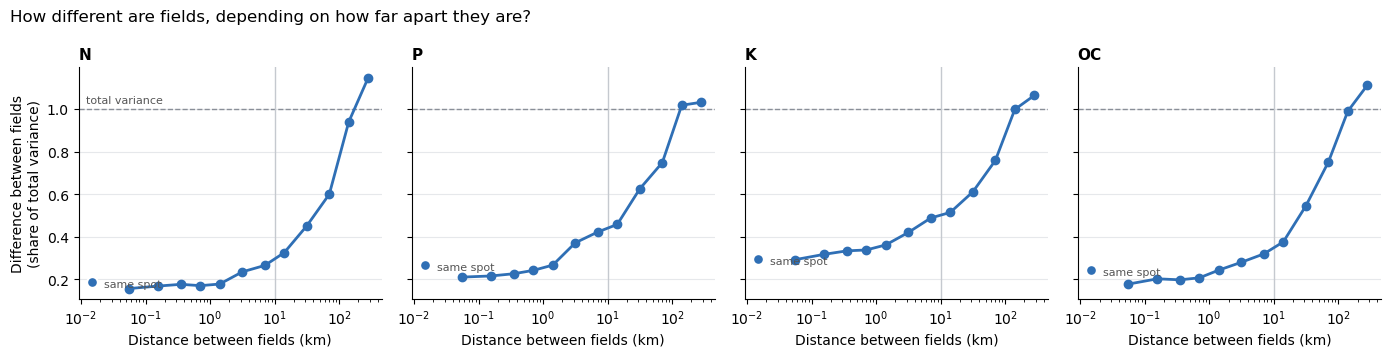

In [18]:
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.spatial.distance import pdist

lat_r = np.deg2rad(data["latitude"].to_numpy())
xy = np.c_[data["longitude"].to_numpy() * 111320 * np.cos(lat_r), data["latitude"].to_numpy() * 110574]
Z = np.log1p(data[TARGETS].to_numpy())                    # same log scale as the models
total_var = Z.var(axis=0, ddof=1)

BINS = np.array([30, 100, 250, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 400000])
mid_km = np.sqrt(BINS[:-1] * BINS[1:]) / 1000

# short distances (< 5 km): every pair of locations
p = cKDTree(xy).query_pairs(5000, output_type="ndarray")
d_short = np.hypot(*(xy[p[:, 0]] - xy[p[:, 1]]).T)
# long distances: all pairs among a random sample of 4,000 locations
rng = np.random.default_rng(SEED)
s = rng.choice(len(xy), 4000, replace=False)
d_long = pdist(xy[s])
i_l, j_l = np.triu_indices(len(s), 1)

rows = []
for k, t in enumerate(TARGETS):
    g_short = 0.5 * (Z[p[:, 0], k] - Z[p[:, 1], k]) ** 2
    g_long  = 0.5 * (Z[s][i_l, k] - Z[s][j_l, k]) ** 2
    for b in range(len(BINS) - 1):
        lo, hi = BINS[b], BINS[b + 1]
        d, g = (d_short, g_short) if hi <= 5000 else (d_long, g_long)
        m = (d >= lo) & (d < hi)
        rows.append({"target": t, "dist_km": mid_km[b], "range": f"{lo/1000:g}-{hi/1000:g} km",
                     "pairs": int(m.sum()), "semivariance": g[m].mean(),
                     "relative": g[m].mean() / total_var[k]})
vg = pd.DataFrame(rows)
vg.to_csv(RES_DIR / "19_semivariogram.csv", index=False)

# nugget = disagreement of samples at the same spot (E07), relative to total variance
nc = pd.read_csv(RES_DIR / "06_noise_ceiling.csv").set_index("target")
nugget = (nc["var_same_spot"] / nc["var_total"]).to_dict()

print("Relative semivariance (1.0 = total variance of the state):")
print(vg.pivot(index="range", columns="target", values="relative").reindex(vg["range"].unique())[TARGETS].round(2).to_string())
print("\nSame-spot (nugget) share of total variance:", {t: round(nugget[t], 2) for t in TARGETS})
for t in TARGETS:
    v = vg[vg["target"] == t]
    reach = v[v["relative"] >= 0.95]
    print(f"{t}: reaches 95 % of total variance at about {reach['dist_km'].iloc[0]:.0f} km" if len(reach)
          else f"{t}: still below 95 % of total variance at 400 km")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=True)
for ax, t in zip(axes, TARGETS):
    v = vg[vg["target"] == t]
    ax.axhline(1.0, color="#8a8f98", lw=1, ls="--")
    ax.axvline(10, color="#c5c9cf", lw=1)
    ax.plot(v["dist_km"], v["relative"], color="#2f6fb5", lw=2, marker="o", ms=6)
    ax.scatter([0.015], [nugget[t]], s=60, color="#2f6fb5", edgecolor="white", linewidth=1.5, zorder=3)
    ax.annotate("same spot", (0.015, nugget[t]), textcoords="offset points", xytext=(8, -4), fontsize=8, color="#555")
    ax.set_xscale("log")
    ax.set_title(t, loc="left", fontsize=11, fontweight="bold")
    ax.set_xlabel("Distance between fields (km)")
    ax.grid(axis="y", color="#e6e8eb", lw=0.8)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
axes[0].set_ylabel("Difference between fields\n(share of total variance)")
axes[0].annotate("total variance", (0.012, 1.0), textcoords="offset points", xytext=(0, 4), fontsize=8, color="#555")
axes[0].annotate("10 km block", (10, 0.05), textcoords="offset points", xytext=(4, 0), fontsize=8, color="#555")
fig.suptitle("How different are fields, depending on how far apart they are?", x=0.01, ha="left", fontsize=12)
fig.tight_layout()
fig.savefig(RES_DIR / "19_semivariogram.png", dpi=200)
plt.show()
